In [56]:
import sys
sys.path.append("/mnt/home/dgolez/Projects/dmft/github/nessi/libcntr/python3")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import simps
import h5py
from ReadCNTR import Dummy
from scipy.interpolate import interp1d
from ReadCNTRhdf5 import read_imp_h5file,read_imp_h5file_slices
import glob
from scipy.linalg import eigvalsh
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
import scipy.io
from matplotlib import colors
import math
from matplotlib.ticker import FuncFormatter

def get_ft(At, dt,factorreim, use_window=False, reverse=False, scale=10):
    """ Fourier transform of real-time function to frequency space
    
    Using the assumption that the function has a step at t=0,
    the data is "up-folded" from [0, t_max] to [-t_max, t_max]
    by concatenating the reversed conj(At) and At obtaining a 
    doulbed but still continous function at t=0. 

    Works for time translational invariant response functions of 
    the type G(t, t_f) for fixed t_f. To handle the opposite case
    G(t_f, t) (e.g. for the lesser Green's function), set reverse=True.

    Arguments:

        At - response function in one time variable
        dt - time discretization

        use_window - use of a fft window to smooth out
                     discontinuities at t = t_max

        reverse - the response function is of the form 
                  G(t) = G(0, t) = G(0 - t)

        scale - number of frequency points per time step
    
    Returns:

        w - the angular frequency
        Aw - the function transformed to (angular) frequency space.

    """

    t = np.arange(len(At)) * dt

    At_org, t_org = At, t

    # -- Concatenate signal with a mirror copy
    # -- this also gives a time shift of T
    # -- that has to be canceled by a phase in frequency space

    if reverse:
        At = np.concatenate((At[::-1], -At[1:].conj(), ))
        t = np.concatenate((-t[::-1], t[1:]))
    else:
        At = np.concatenate((factorreim*At[::-1].conj(), At[1:]))
        t = np.concatenate((-t[::-1], t[1:]))

    # -- Windowing
    if use_window: window = np.blackman(len(At)) 
    else:          window = 1.0

    # -- DFT with zero padding
    N = scale*len(At)

    Aw = 0.5*N*dt * np.fft.ifft(At * window, N)
    Aw = np.fft.fftshift(Aw)

    w = 2.*np.pi * np.fft.fftfreq(N, d=dt)
    w = np.fft.fftshift(w)

    # Phase fix, compensating for the shift in zero time 
    # caused by the concatenation in real time above
    tmax = t[-1]
    Aw *= np.exp(-1.j*w*tmax)

    #print 'len(At_org) =', len(At_org)
    #print 'len(At_ext) =', len(At)
    #print 'scale =', scale
    #print 'N =', N

    if False:
        # -- Debug Plotting
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,12))
        subp = [3, 1, 1]

        plt.subplot(*subp); subp[-1] += 1
        plt.plot(t_org, At_org.real, 'b', label='Re')
        plt.plot(t_org, At_org.imag, 'g', label='Im')
        plt.legend(loc='best', frameon=False)
        plt.xlabel(r'$t$')

        plt.subplot(*subp); subp[-1] += 1
        plt.plot(t, At.real, 'b', label='Re')
        plt.plot(t, At.imag, 'g', label='Im')
        plt.plot(t, At.real*window, 'c', label='win Re')
        plt.plot(t, At.imag*window, 'm', label='win Im')
        plt.legend(loc='best', frameon=False)
        plt.xlabel(r'$-t,t$')

        plt.subplot(*subp); subp[-1] += 1
        plt.plot(freq, Aw.real, 'b', label='Re')
        plt.plot(freq, Aw.imag, 'g', label='Im')
        plt.plot(freq, np.abs(Aw), 'r', label='Abs')

        plt.legend(loc='best', frameon=False)
        plt.xlabel(r'$\omega$')

        plt.show()
        exit()

    return w, Aw

def norm(pval,pmin,pmax):
    return (pval - pmin) / float(pmax - pmin)

def anal_les(G,dt,k,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow,dt)
#     print(twindow+tslice)
    for indx in np.where(np.abs(steps-twindow-tslice)<2e-2)[0]:
        slicetrace=np.trace(G.les[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral
        
        return np.array([freq,Aw.imag/np.pi])

    
def anal_ret(G,dt,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow,dt)
    for indx in np.where(np.abs(steps-twindow-tslice)<5e-1)[0]:
        slicetrace=np.trace(G.ret[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral        
        return np.array([-freq,-Aw.imag/np.pi])

def plot_Akw(folder,tslice,eta,ax,label):
    allfiles=glob.glob("{}/out_k*.out".format(folder))
    twindow=30.0
    # Set length
    imp = read_imp_h5file_slices(allfiles[0],["G","parm"])
    dt=imp.parm.h[0]
    lengthsec=anal_les(imp.G,imp.parm.h[0],imp.parm.kk[0],tslice,twindow,eta).shape[1]
    ret=np.zeros((len(allfiles)*2-1,2,lengthsec))
    les=np.zeros((len(allfiles)*2-1,2,lengthsec))
    indxfiles=0
    kpoints=np.zeros(len(allfiles))
    for files in allfiles:
#         print('--> Loading:', files)
        imp = read_imp_h5file_slices(files,["G","parm"])
        t=np.arange(0,imp.parm.nt)*dt
        G = imp.G
        kpoints[indxfiles]=imp.parm.kk[0]
#         ret[indxfiles,:,:]=anal_les(G,dt,imp.parm.kk[0],tslice,twindow,eta)
        ret[indxfiles,:,:]=anal_ret(G,dt,tslice,twindow,eta)
        indxfiles+=1
    index=kpoints.argsort()
    #pos=ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi,np.pi,-ret[0,0,0],ret[0,0,0]),interpolation="bilinear",origin='lower',vmax=1.0,vmin=1e-3,cmap="terrain")
    #pos=ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi,np.pi,-ret[0,0,0],ret[0,0,0]),interpolation="bilinear",norm=LogNorm(vmin=1e-3, vmax=2.0),origin='lower',vmax=2.0,vmin=1e-3,cmap="terrain")
#     ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=5.0,vmin=1e-2, norm=colors.PowerNorm(gamma=0.6),cmap="terrain",aspect='auto')
    ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=5.0,vmin=1e-2,cmap="terrain",aspect='auto')
    ax.set_title("${}$".format(label))
    
    #axtmp = ax.twinx()
    #axtmp._sharex = ax
    #formatter = FuncFormatter(lambda x, pos: '{:0.2f}'.format(x*0.26))
    #axtmp.set_xlim(ax.get_xlim())

def plot_disper(folder,ax,color="w",mu=0.0):
    allfiles=glob.glob("{}/out_denk*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    eigen=np.zeros((len(allfiles),2))
    eff=np.zeros((len(allfiles),2))
    for [i,files] in enumerate(allfiles):
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
        kpoints[i]=imp.parm.kk[0]
        eigen[i,:]=np.array([imp.hkeff_eigen.data[0,0,0],imp.hkeff_eigen.data[0,1,1]])
        eff[i,:]=np.array([imp.hkeff.data[0,0,0],imp.hkeff.data[0,1,1]])
    
    index=kpoints.argsort()
    eps0=(eigen[index,0]-mu)*0.33
    eps1=(eigen[index,1]-mu)*0.33
    
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-mu)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-mu)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-mu)*0.33,ls="--",color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-mu)*0.33,ls="--",color=color)
    print(np.min(eps1)-np.max(eps0))

In [ ]:
# estimation of temperature

In [ ]:
0.33*

In [25]:
U=2.8
lam=0.1
print(U*0.33,lam*0.33)

0.9239999999999999 0.033


In [26]:
U=0.4
lam=1.3
print(U*0.33,lam*0.33)

0.132 0.42900000000000005


# Fig1a

In [39]:
hop=0.33
time=1.96

In [ ]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subpl ot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)


#----- U=2.8/delta=1.3
folder="../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax0,label="Eq")
plot_disper(folder,ax=ax0,color="w",mu=0.284127547569)

#----- U=0.5
folder="../abinitio/2bHYB/calc_U0.5_E00.0_om6.0_om00.05_lam1.25_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax1,label="Eq")
plot_disper(folder,ax=ax1,color="w",mu=0.284127547569)

folder="../abinitio/2bHYB/calc_U0.5_E00.0_om6.0_om00.05_lam1.25_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax1,color="w",mu=0.284127547569)


#----- U=1.5
folder="../abinitio/2bHYB/calc_U1.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax2,label="Eq")
plot_disper(folder,ax=ax2,color="w",mu=0.284127547569)

folder="../abinitio/2bHYB/calc_U1.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax2,color="w",mu=0.284127547569)



ax0.set_xlim([-0.3,0.3])
ax0.set_ylim([-0.2,0.2])
ax0.set_xlabel("$k~[A^{-1}]$")
ax0.set_ylabel("$\omega~[eV]$")
ax0.set_title("Eq")


ax1.set_xlim([-0.3,0.3])
ax1.set_ylim([-0.2,0.2])
ax1.set_xlabel("$k~[A^{-1}]$")
ax1.set_ylabel("$\omega~[eV]$")
ax1.set_title("Eq")

ax2.set_xlim([-0.3,0.3])
ax2.set_ylim([-0.2,0.2])
ax2.set_xlabel("$k~[A^{-1}]$")
ax2.set_ylabel("$\omega~[eV]$")
ax2.set_title("Eq")

plt.subplots_adjust(wspace = 0.01)
#plt.tight_layout()
plt.savefig("fin/fig1a.pdf")

/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:188: ComplexWarning: Casting complex values to real discards the imaginary part


0.24105055758378244


/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:188: ComplexWarning: Casting complex values to real discards the imaginary part


0.23409241861701693
0.2692023293292532
0.231253780087711
0.2258165338324804
0.22016875736856956
0.21429512823659458


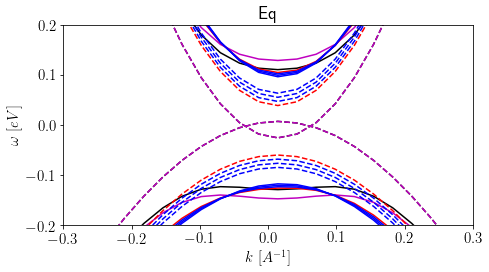

In [92]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(1,1,1)

folder="../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.284127547569_beta10.0_ntau2000_dt0.02_err3e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="k",mu=0.2801219667)

folder="../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta40.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="m",mu=0.2801219667)

folder="../abinitio/2bHYB/calc_U2.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.4_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="r",mu=0.284127547569)

folder="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.45_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="b",mu=0.284127547569)

folder="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.5_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="b",mu=0.284127547569)

folder="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.55_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
plot_disper(folder,ax=ax0,color="b",mu=0.284127547569)

ax0.set_xlim([-0.3,0.3])
ax0.set_ylim([-0.2,0.2])
ax0.set_xlabel("$k~[A^{-1}]$")
ax0.set_ylabel("$\omega~[eV]$")
ax0.set_title("Eq")

plt.subplots_adjust(wspace = 0.01)
#plt.tight_layout()
# plt.savefig("fin/fig1a.pdf")

# Fig1b

In [14]:
def anal_les(G,dt,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow,dt)
#     print(np.abs(steps-twindow-tslice))
    for indx in np.where(np.abs(steps-twindow-tslice)<6e-1)[0]:
#         print(indx,G.steps[indx])
        slicetrace=np.trace(G.les[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*eta*time[::-1]*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral
        
        return np.array([freq,Aw.imag/np.pi])

def anal_ret(G,dt,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow+dt,dt)
#     print(np.abs(steps-twindow-tslice))
    for indx in np.where(np.abs(steps-twindow-tslice)<6e-1)[0]:
#         print(indx,G.steps[indx])
        slicetrace=np.trace(G.ret[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral
        
        return np.array([-freq,-Aw.imag/np.pi])

def get_kslice(file,tslice,twindow):
#     assert (tslice >= twindow),"Slice shorter than window"
    eta=1.0/twindow
    imp = read_imp_h5file_slices(file,["G","parm"])
    t=np.arange(0,imp.parm.nt)*imp.parm.h[0]
    G = imp.G
#     print(imp.parm.kk[0]/3.5)
    [ome,Nw]=anal_les(G,imp.parm.h[0],tslice,twindow,eta)
#     [ome,Nw]=anal_ret(G,imp.parm.h[0],tslice,twindow,eta)
    return [-ome,Nw]

def get_range(datax,datay,t1,t2):
    sidx = np.logical_and(t1<datax,datax<t2)
    return [datax[sidx],datay[sidx]]

../abinitio/2bHYB/calc_U0.4_E00.0_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k32.out
-0.3302934702722434
-0.32471622848288006
-0.31760419941512663
../abinitio/2bHYB/calc_U0.4_E00.0_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k29.out
-0.33024829072244327
-0.322852396957912
-0.3166574299317104
../abinitio/2bHYB/calc_U0.4_E00.0_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k26.out
-0.33002713956815405
-0.3274725471996183
-0.32331930112508417


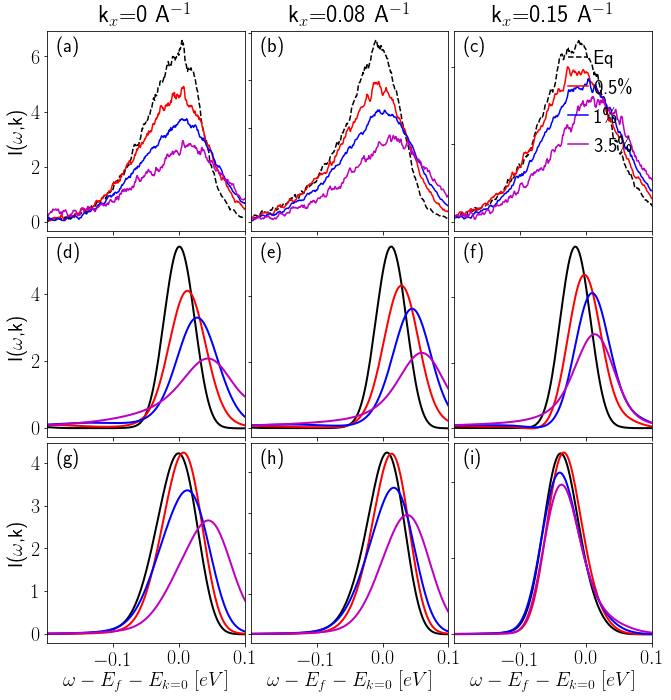

In [20]:
# %matplotlib inline
mpl.rcParams['font.size'] = 20
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


ome = np.linspace(-0.4,0.1,100)
kpoints=np.array([32,29,26])
twindow=50.0

fig, ax = plt.subplots(3, 3,figsize=(10,10))

# Experiment
energy=np.loadtxt("expVancouver/Energy.txt")
datak0_E26=np.loadtxt("expVancouver/EDC_k0_25uJ.txt")
datak0_E50=np.loadtxt("expVancouver/EDC_k0_50uJNEW.txt")
datak0_E160=np.loadtxt("expVancouver/EDC_k0_160uJ.txt")

ax[0,0].plot(energy+0.1420,datak0_E26[0,:],"k--")
ax[0,0].plot(energy+0.1420,datak0_E26[-1,:],"r-")
ax[0,0].plot(energy+0.1420-0.005,datak0_E50[-1,:],"b-")
ax[0,0].plot(energy+0.1420-0.025,datak0_E160[-1,:],"m-")

datak08_E26=np.loadtxt("expVancouver/EDC_k08_26uJ.txt")
datak08_E50=np.loadtxt("expVancouver/EDC_k08_50uJ.txt")
datak08_E160=np.loadtxt("expVancouver/EDC_k08_160uJ.txt")

ax[0,1].plot(energy+0.1389,datak08_E26[0,:],"k--")
ax[0,1].plot(energy+0.1389,datak08_E26[-1,:],"r-")
ax[0,1].plot(energy+0.1389-0.005,datak08_E50[-1,:],"b-")
ax[0,1].plot(energy+0.1389-0.025,datak08_E160[-1,:],"m-")


datak15_E26=np.loadtxt("expVancouver/EDC_k15_26uJ.txt")
datak15_E50=np.loadtxt("expVancouver/EDC_k15_50uJ.txt")
datak15_E160=np.loadtxt("expVancouver/EDC_k15_160uJ.txt")

ax[0,2].plot(energy+0.217-0.01,datak15_E26[0,:],"k--",label="Eq")
ax[0,2].plot(energy+0.217-0.01,datak15_E26[-1,:],"r-",label="0.5\%")
ax[0,2].plot(energy+0.217-0.01-0.005,datak15_E50[-1,:],"b-",label="1\%")
ax[0,2].plot(energy+0.217-0.01-0.025,datak15_E160[-1,:],"m-",label="3.5\%")



for [indxk,k] in enumerate(kpoints):
    file="../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[1,indxk].plot(ome*0.33+0.12857968732235883,Nw,"k-",lw=2)
    np.savetxt("data/fig3_U28_Eq_k{}.txt".format(indxk),np.array([ome*0.33+0.12857968732235883,Nw]).T)
    
    # dn=0.5 %
    file="../abinitio/2bHYB/calc_U2.8_E00.16_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.12857968732235883,Nw,"r-",lw=2)
    np.savetxt("data/fig3_U28_n05_k{}.txt".format(indxk),np.array([ome*0.33+0.12857968732235883,Nw]).T)
    
    # dn=1 %
    file="../abinitio/2bHYB/calc_U2.8_E00.22_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta17.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.12650582139780464,Nw,"b-",lw=2)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U28_n1_k{}.txt".format(indxk),np.array([ome*0.33+0.12650582139780464,Nw]).T)
    
    # dn=3.5 %
    file="../abinitio/2bHYB/calc_U2.8_E00.33_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta10.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.1099,Nw,"m-",lw=2)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U28_n35_k{}.txt".format(indxk),np.array([(ome)*0.33+0.1099,Nw]).T)




# Lattice    
for [indxk,k] in enumerate(kpoints):
    file="../abinitio/2bHYB/calc_U0.4_E00.0_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    print(file)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.1389490,Nw,"k-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U04_Eq_k{}.txt".format(indxk),np.array([(ome)*0.33+0.1389490,Nw]).T)
    
    # 0.5 %
    file="../abinitio/2bHYB/calc_U0.4_E00.45_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.1389490,Nw,"r-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U04_n05_k{}.txt".format(indxk),np.array([(ome)*0.33+0.1389490,Nw]).T)
    
    # 1.0 %
    file="../abinitio/2bHYB/calc_U0.4_E00.6_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.1306535,Nw,"b-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U04_n1_k{}.txt".format(indxk),np.array([(ome)*0.33+0.1306535,Nw]).T)
        
#     # 3.5 %
    file="../abinitio/2bHYB/calc_U0.4_E01.2_om6.0_om00.05_lam1.3_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta13.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.1161364917,Nw,"m-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U04_n35_k{}.txt".format(indxk),np.array([(ome)*0.33+0.1161364917,Nw]).T)

    
ax[0,0].set_xlim(-0.2,0.0)
ax[0,1].set_xlim(-0.2,0.0)
ax[0,2].set_xlim(-0.2,0.0)

ax[1,0].set_xlim(-0.2,0.0)
ax[1,1].set_xlim(-0.2,0.0)
ax[1,2].set_xlim(-0.2,0.0)

ax[2,0].set_xlim(-0.2,0.0)
ax[2,1].set_xlim(-0.2,0.0)
ax[2,2].set_xlim(-0.2,0.0)

ax[0,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[0,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[0,2].set_xticks(np.array([-0.1,0.0,0.1]))

ax[1,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[1,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[1,2].set_xticks(np.array([-0.1,0.0,0.1]))

ax[2,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[2,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[2,2].set_xticks(np.array([-0.1,0.0,0.1]))

#Set x-axis
ax[0,0].get_xaxis().set_ticklabels([])
ax[0,1].get_xaxis().set_ticklabels([])
ax[0,2].get_xaxis().set_ticklabels([])
ax[1,0].get_xaxis().set_ticklabels([])
ax[1,1].get_xaxis().set_ticklabels([])
ax[1,2].get_xaxis().set_ticklabels([])
#Set y-axis
ax[0,1].get_yaxis().set_ticklabels([])
ax[0,2].get_yaxis().set_ticklabels([])
ax[1,1].get_yaxis().set_ticklabels([])
ax[1,2].get_yaxis().set_ticklabels([])
ax[2,1].get_yaxis().set_ticklabels([])
ax[2,2].get_yaxis().set_ticklabels([])


ax[0,0].set_title("k$_x$=0 A$^{-1}$")
ax[0,1].set_title("k$_x$=0.08 A$^{-1}$")
ax[0,2].set_title("k$_x$=0.15 A$^{-1}$")
ax[0,0].text(0.05,0.9,"(a)",transform=ax[0,0].transAxes)
ax[0,1].text(0.05,0.9,"(b)",transform=ax[0,1].transAxes)
ax[0,2].text(0.05,0.9,"(c)",transform=ax[0,2].transAxes)


ax[0,0].set_ylabel("I($\omega$,k)")
ax[1,0].set_ylabel("I($\omega$,k)")
ax[2,0].set_ylabel("I($\omega$,k)")
ax[1,0].text(0.05,0.9,"(d)",transform=ax[1,0].transAxes)
ax[1,1].text(0.05,0.9,"(e)",transform=ax[1,1].transAxes)
ax[1,2].text(0.05,0.9,"(f)",transform=ax[1,2].transAxes)


ax[2,0].set_xlabel("$\omega-E_f-E_{k=0}~[eV]$")
ax[2,1].set_xlabel("$\omega-E_f-E_{k=0}~[eV]$")
ax[2,2].set_xlabel("$\omega-E_f-E_{k=0}~[eV]$")
ax[2,0].text(0.05,0.9,"(g)",transform=ax[2,0].transAxes)
ax[2,1].text(0.05,0.9,"(h)",transform=ax[2,1].transAxes)
ax[2,2].text(0.05,0.9,"(i)",transform=ax[2,2].transAxes)

ax[0,2].legend(loc=1,frameon=False,handlelength=1,handletextpad=0.3)

plt.subplots_adjust(wspace = 0.03,hspace=0.03)
plt.savefig("fin/fig3.pdf")

# Fig1b - OLD

-0.3303110563386183
-0.32629182107824795
../abinitio/2bHYB/calc_U0.2_E00.6_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k32.out
-0.3204405886238393
-0.33026845362256807
-0.32493560584883946
../abinitio/2bHYB/calc_U0.2_E00.6_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k29.out
-0.31975431861118425
-0.33004023525000364
-0.32804007283199726
../abinitio/2bHYB/calc_U0.2_E00.6_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k26.out
-0.32463083934701986


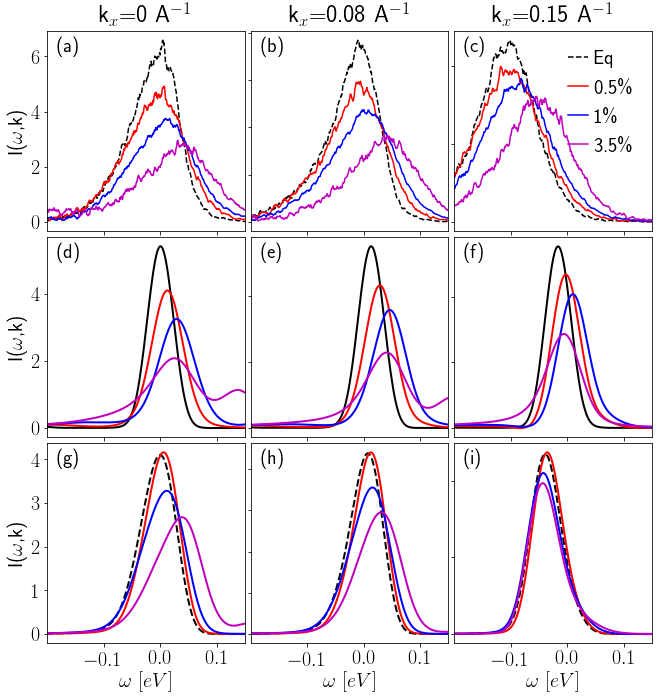

In [72]:
# %matplotlib inline
mpl.rcParams['font.size'] = 20
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


ome = np.linspace(-0.4,0.1,100)
kpoints=np.array([32,29,26])
twindow=50.0

fig, ax = plt.subplots(3, 3,figsize=(10,10))

# Experiment
energy=np.loadtxt("expVancouver/Energy.txt")
datak0_E26=np.loadtxt("expVancouver/EDC_k0_25uJ.txt")
datak0_E50=np.loadtxt("expVancouver/EDC_k0_50uJNEW.txt")
datak0_E160=np.loadtxt("expVancouver/EDC_k0_160uJ.txt")

ax[0,0].plot(energy+0.1420,datak0_E26[0,:],"k--")
ax[0,0].plot(energy+0.1420,datak0_E26[-1,:],"r-")
ax[0,0].plot(energy+0.1420,datak0_E50[-1,:],"b-")
ax[0,0].plot(energy+0.1420,datak0_E160[-1,:],"m-")

datak08_E26=np.loadtxt("expVancouver/EDC_k08_26uJ.txt")
datak08_E50=np.loadtxt("expVancouver/EDC_k08_50uJ.txt")
datak08_E160=np.loadtxt("expVancouver/EDC_k08_160uJ.txt")

ax[0,1].plot(energy+0.1389,datak08_E26[0,:],"k--")
ax[0,1].plot(energy+0.1389,datak08_E26[-1,:],"r-")
ax[0,1].plot(energy+0.1389,datak08_E50[-1,:],"b-")
ax[0,1].plot(energy+0.1389,datak08_E160[-1,:],"m-")


datak15_E26=np.loadtxt("expVancouver/EDC_k15_26uJ.txt")
datak15_E50=np.loadtxt("expVancouver/EDC_k15_50uJ.txt")
datak15_E160=np.loadtxt("expVancouver/EDC_k15_160uJ.txt")

ax[0,2].plot(energy+0.1169,datak15_E26[0,:],"k--",label="Eq")
ax[0,2].plot(energy+0.1169,datak15_E26[-1,:],"r-",label="0.5\%")
ax[0,2].plot(energy+0.1169,datak15_E50[-1,:],"b-",label="1\%")
ax[0,2].plot(energy+0.1169,datak15_E160[-1,:],"m-",label="3.5\%")




for [indxk,k] in enumerate(kpoints):
    file="../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[1,indxk].plot(ome*0.33+0.12857968732235883,Nw,"k-",lw=2)
    
    # dn=0.5 %
    file="../abinitio/2bHYB/calc_U2.8_E00.16_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.12857968732235883,Nw,"r-",lw=2)
    
    # dn=1 %
    file="../abinitio/2bHYB/calc_U2.8_E00.22_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta15.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.12650582139780464,Nw,"b-",lw=2)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    
    # dn=3.5 %
    file="../abinitio/2bHYB/calc_U2.8_E00.33_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta10.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome)*0.33+0.091,Nw,"m-",lw=2)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)


# Lattice    
for [indxk,k] in enumerate(kpoints):
    file="../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
#     print(file)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.138949,Nw,"k--",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
#     file="../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
#     [ome,Nw]=get_kslice(file,30.0,twindow)
#     ax[2,indxk].plot((ome)*0.33+0.1265058213,Nw,"k-.",lw=2,label="Eq")

    # 0.5 
    file="../abinitio/2bHYB/calc_U0.2_E00.45_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.138949,Nw,"r-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
#     file="../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
#     [ome,Nw]=get_kslice(file,30.0,twindow)
#     ax[2,indxk].plot((ome)*0.33+0.1368751,Nw,"r--",lw=2,label="Eq")
    
    # 1.0 %
    file="../abinitio/2bHYB/calc_U0.2_E00.6_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    print(file)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.13065355,Nw,"b-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)

        
#     # 3.5 %
    file="../abinitio/2bHYB/calc_U0.2_E01.2_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta13.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome)*0.33+0.116136,Nw,"m-",lw=2,label="Eq")
    [x,y]=get_range((ome)*0.33,Nw,-2,0)
    omP=np.flip((ome)*0.33)
    NwP=np.flip(Nw)
    
ax[0,0].set_xlim(-0.2,0.15)
ax[0,1].set_xlim(-0.2,0.15)
ax[0,2].set_xlim(-0.2,0.15)

ax[1,0].set_xlim(-0.2,0.15)
ax[1,1].set_xlim(-0.2,0.15)
ax[1,2].set_xlim(-0.2,0.15)

ax[2,0].set_xlim(-0.2,0.15)
ax[2,1].set_xlim(-0.2,0.15)
ax[2,2].set_xlim(-0.2,0.15)

ax[0,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[0,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[0,2].set_xticks(np.array([-0.1,0.0,0.1]))

ax[1,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[1,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[1,2].set_xticks(np.array([-0.1,0.0,0.1]))



ax[2,0].set_xticks(np.array([-0.1,0.0,0.1]))
ax[2,1].set_xticks(np.array([-0.1,0.0,0.1]))
ax[2,2].set_xticks(np.array([-0.1,0.0,0.1]))

#Set x-axis
ax[0,0].get_xaxis().set_ticklabels([])
ax[0,1].get_xaxis().set_ticklabels([])
ax[0,2].get_xaxis().set_ticklabels([])
ax[1,0].get_xaxis().set_ticklabels([])
ax[1,1].get_xaxis().set_ticklabels([])
ax[1,2].get_xaxis().set_ticklabels([])
#Set y-axis
ax[0,1].get_yaxis().set_ticklabels([])
ax[0,2].get_yaxis().set_ticklabels([])
ax[1,1].get_yaxis().set_ticklabels([])
ax[1,2].get_yaxis().set_ticklabels([])
ax[2,1].get_yaxis().set_ticklabels([])
ax[2,2].get_yaxis().set_ticklabels([])


ax[0,0].set_title("k$_x$=0 A$^{-1}$")
ax[0,1].set_title("k$_x$=0.08 A$^{-1}$")
ax[0,2].set_title("k$_x$=0.15 A$^{-1}$")
ax[0,0].text(0.05,0.9,"(a)",transform=ax[0,0].transAxes)
ax[0,1].text(0.05,0.9,"(b)",transform=ax[0,1].transAxes)
ax[0,2].text(0.05,0.9,"(c)",transform=ax[0,2].transAxes)


ax[0,0].set_ylabel("I($\omega$,k)")
ax[1,0].set_ylabel("I($\omega$,k)")
ax[2,0].set_ylabel("I($\omega$,k)")
ax[1,0].text(0.05,0.9,"(d)",transform=ax[1,0].transAxes)
ax[1,1].text(0.05,0.9,"(e)",transform=ax[1,1].transAxes)
ax[1,2].text(0.05,0.9,"(f)",transform=ax[1,2].transAxes)


ax[2,0].set_xlabel("$\omega~[eV]$")
ax[2,1].set_xlabel("$\omega~[eV]$")
ax[2,2].set_xlabel("$\omega~[eV]$")
ax[2,0].text(0.05,0.9,"(g)",transform=ax[2,0].transAxes)
ax[2,1].text(0.05,0.9,"(h)",transform=ax[2,1].transAxes)
ax[2,2].text(0.05,0.9,"(i)",transform=ax[2,2].transAxes)

ax[0,2].legend(loc=1,frameon=False,handlelength=1,handletextpad=0.3)

plt.subplots_adjust(wspace = 0.03,hspace=0.03)
plt.savefig("fin/fig3_alter.pdf")

# Fig 1b

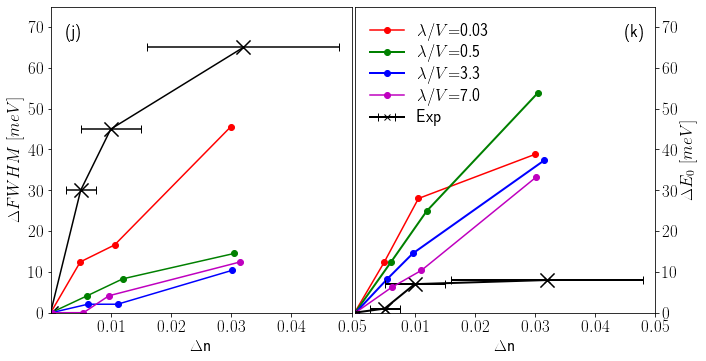

In [57]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95



fig, ax = plt.subplots(1,2,figsize=(10,5))


lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow

bath=False

doping1=np.loadtxt("doping_U2.8.txt")
shift1=np.loadtxt("shifts_U2.8.txt")
shiftT1=np.loadtxt("shiftT_U2.8.txt")


doping2=np.loadtxt("doping_U1.5.txt")
shift2=np.loadtxt("shifts_U1.5.txt")
shiftT2=np.loadtxt("shiftsT_U1.5.txt")


doping4=np.loadtxt("doping_U0.4.txt")
shift4=np.loadtxt("shifts_U0.4.txt")
shiftT4=np.loadtxt("shiftsT_U0.4.txt")


doping5=np.loadtxt("doping_U0.2.txt")
shift5=np.loadtxt("shifts_U0.2.txt")
shiftT5=np.loadtxt("shiftsT_U0.2.txt")



ax[0].plot(doping1[:,1],(shift1[:,3]-shiftT1[:,1])*1000-(shift1[0,3]-shiftT1[0,1])*1000,"r-",marker="o",label="$\lambda/V$=0.03")
np.savetxt("data/fig3j_lV003.txt",np.array([doping1[:,1],(shift1[:,3]-shiftT1[:,1])*1000-(shift1[0,3]-shiftT1[0,1])*1000]).T)
ax[0].plot(doping2[:,1],(shift2[:,3]-shiftT2[:,1])*1000-(shift2[0,3]-shiftT2[0,1])*1000,"g-",marker="o",label="$\lambda/V$=0.5")
np.savetxt("data/fig3j_lV05.txt",np.array([doping2[:,1],(shift2[:,3]-shiftT2[:,1])*1000-(shift2[0,3]-shiftT2[0,1])*1000]).T)
ax[0].plot(doping4[:,1],np.abs((shift4[:,3]-shiftT4[:,1])*1000-(shift4[0,3]-shiftT4[0,1])*1000),"b-",marker="o",label="$\lambda/V$=3.3")
np.savetxt("data/fig3j_lV33.txt",np.array([doping4[:,1],np.abs((shift4[:,3]-shiftT4[:,1])*1000-(shift4[0,3]-shiftT4[0,1])*1000)]).T)
ax[0].plot(doping5[:,1],np.abs((shift5[:,3]-shiftT5[:,1])*1000-(shift5[0,3]-shiftT5[0,1])*1000),"m-",marker="o",label="$\lambda/V$=7.0")
np.savetxt("data/fig3j_lV7.txt",np.array([doping5[:,1],np.abs((shift5[:,3]-shiftT5[:,1])*1000-(shift5[0,3]-shiftT5[0,1])*1000)]).T)


ax[0].set_xlabel("$\Delta$n")
ax[0].set_ylabel("$\Delta FWHM~[meV]$")

fluence=np.array([0,0.005,0.01,0.032])
shiftE0=np.array([0,30,45,65])

ax[0].errorbar(fluence,shiftE0,xerr=fluence*0.5,capsize=4,color="k",label="Exp")
ax[0].scatter(fluence,shiftE0,s = 200, marker = "x", color = "k")


ax[1].plot(doping1[:,1],(shift1[:,1]-shiftT1[:,0]-(shift1[0,1]-shiftT1[0,0]))*1000,"r-",marker="o",label="$\lambda/V$=0.03")
np.savetxt("data/fig3k_lV003.txt",np.array([doping1[:,1],(shift1[:,1]-shiftT1[:,0]-(shift1[0,1]-shiftT1[0,0]))*1000]).T)
# ax[1].plot(doping2[:,1],(shift2[:,1]-shiftT2[:]-(shift2[0,1]-shiftT2[0]))*1000,"b-",marker="o",label="$\lambda/V$=0.5")
ax[1].plot(doping2[:,1],(shift2[:,1]-shiftT2[:,0])*1000,"g-",lw=2,marker="o",label="$\lambda/V$=0.5")
np.savetxt("data/fig3k_lV05.txt",np.array([doping2[:,1],(shift2[:,1]-shiftT2[:,0])*1000]).T)
ax[1].plot(doping5[:,1],(shift4[:,1]-shiftT4[:,0]-(shift4[0,1]-shiftT4[0,0]))*1000,"b-",lw=2,marker="o",label="$\lambda/V$=3.3")
np.savetxt("data/fig3k_lV33.txt",np.array([doping5[:,1],(shift4[:,1]-shiftT4[:,0]-(shift4[0,1]-shiftT4[0,0]))*1000]).T)
ax[1].plot(doping4[:,1],(shift5[:,1]-shiftT5[:,0]-(shift5[0,1]-shiftT5[0,0]))*1000,"m-",marker="o",label="$\lambda/V$=7.0")
np.savetxt("data/fig3k_lV7.txt",np.array([doping4[:,1],(shift5[:,1]-shiftT5[:,0]-(shift5[0,1]-shiftT5[0,0]))*1000]).T)

fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
ax[1].errorbar(fluence,shift,xerr=fluence*0.5,color="k",marker="x",capsize=4,lw=2,label="Exp")
ax[1].scatter(fluence, shift, s = 200, marker = "x", color = "k")


ax[1].set_ylabel("$d\mu~[meV]$")
ax[1].set_xlabel("$\Delta$n")
ax[1].set_ylabel("$\Delta E_0~[meV]$")

ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()


plt.subplots_adjust(wspace=0.01)

ax[0].set_ylim(0,75)
ax[1].set_ylim(0,75)
ax[0].set_xlim(1e-5,0.05)
ax[1].set_xlim(1e-5,0.05)

ax[1].legend(loc=2,frameon=False,labelspacing=0.2)
ax[0].text(0.05,0.9,"(j)",transform=ax[0].transAxes)
ax[1].text(0.9,0.9,"(k)",transform=ax[1].transAxes)

plt.savefig("fin/fig3b.pdf")

Err:  [ 0.          3.60218732  7.75930051 21.88904643]
Err:  [0.         1.40305701 2.76520678 7.03546691]
Err:  [0.         1.07880768 1.93831188 5.25381631]
Err:  [0.         1.14429914 2.02758829 6.59875797]
----------------------------
Err:  [ 0.          2.95799335  6.3716729  17.97453825]
Err:  [ 0.          5.32298443 10.49077304 26.69148905]
Err:  [ 0.          3.82077441  6.86484955 18.60725254]
Err:  [ 0.          2.87144774  5.08792993 16.55859738]
Err:  [ 0.          2.87144774  5.08792993 16.55859738]


Text(0.9, 0.9, '(k)')

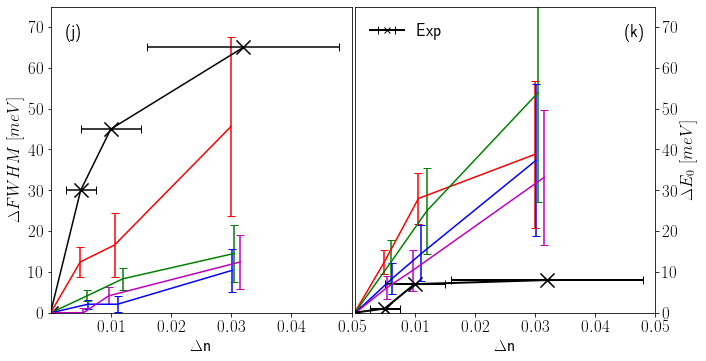

In [34]:
%matplotlib inline
from scipy import stats
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95



fig, ax = plt.subplots(1,2,figsize=(10,5))


lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow

bath=False

doping1=np.loadtxt("doping_U2.8.txt")
shift1=np.loadtxt("shifts_U2.8.txt")
shiftT1=np.loadtxt("shiftT_U2.8.txt")


doping2=np.loadtxt("doping_U1.5.txt")
shift2=np.loadtxt("shifts_U1.5.txt")
shiftT2=np.loadtxt("shiftsT_U1.5.txt")


doping4=np.loadtxt("doping_U0.4.txt")
shift4=np.loadtxt("shifts_U0.4.txt")
shiftT4=np.loadtxt("shiftsT_U0.4.txt")


doping5=np.loadtxt("doping_U0.2.txt")
shift5=np.loadtxt("shifts_U0.2.txt")
shiftT5=np.loadtxt("shiftsT_U0.2.txt")

x=doping1[:,1]
y=(shift1[:,3]-shiftT1[:,1])*1000-(shift1[0,3]-shiftT1[0,1])*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, res.intercept + res.slope*x, 'r--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[0].errorbar(x,y,yerr=err,capsize=4,color="r")
print("Err: ",err)

x=doping2[:,1]
y=(shift2[:,3]-shiftT2[:,1])*1000-(shift2[0,3]-shiftT2[0,1])*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, res.intercept + res.slope*x, 'g--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[0].errorbar(x,y,yerr=err,capsize=4,color="g")
print("Err: ",err)

x=doping4[:,1]
y=(shift4[:,3]-shiftT4[:,1])*1000-(shift4[0,3]-shiftT4[0,1])*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'b--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[0].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="b")
print("Err: ",np.abs(err))

x=doping5[:,1]
y=(shift5[:,3]-shiftT5[:,1])*1000-(shift5[0,3]-shiftT5[0,1])*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'm--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[0].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="m")
print("Err: ",np.abs(err))


ax[0].set_xlabel("$\Delta$n")
ax[0].set_ylabel("$\Delta FWHM~[meV]$")

fluence=np.array([0,0.005,0.01,0.032])
shiftE0=np.array([0,30,45,65])

print("----------------------------")

ax[0].errorbar(fluence,shiftE0,xerr=fluence*0.5,capsize=4,color="k",label="Exp")
ax[0].scatter(fluence,shiftE0,s = 200, marker = "x", color = "k")


x=doping1[:,1]
y=(shift1[:,1]-shiftT1[:,0]-(shift1[0,1]-shiftT1[0,0]))*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'r--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[1].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="r")
print("Err: ",np.abs(err))

x=doping2[:,1]
y=(shift2[:,1]-shiftT2[:,0])*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'g--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[1].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="g")
print("Err: ",np.abs(err))

x=doping4[:,1]
y=(shift4[:,1]-shiftT4[:,0]-(shift4[0,1]-shiftT4[0,0]))*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'b--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[1].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="b")
print("Err: ",np.abs(err))

x=doping5[:,1]
y=(shift5[:,1]-shiftT5[:,0]-(shift5[0,1]-shiftT5[0,0]))*1000
res=scipy.stats.linregress(x,y)
# ax[0].plot(x, np.abs(res.intercept + res.slope*x), 'm--')
err=np.array([0,res.slope*x[1]*0.5,res.slope*x[2]*0.5,res.slope*x[3]*0.5])
ax[1].errorbar(x,np.abs(y),yerr=np.abs(err),capsize=4,color="m")
print("Err: ",np.abs(err))

fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
ax[1].errorbar(fluence,shift,xerr=fluence*0.5,color="k",marker="x",capsize=4,lw=2,label="Exp")
ax[1].scatter(fluence, shift, s = 200, marker = "x", color = "k")
print("Err: ",np.abs(err))

ax[1].set_ylabel("$d\mu~[meV]$")
ax[1].set_xlabel("$\Delta$n")
ax[1].set_ylabel("$\Delta E_0~[meV]$")

ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()


plt.subplots_adjust(wspace=0.01)

ax[0].set_ylim(0,75)
ax[1].set_ylim(0,75)
ax[0].set_xlim(1e-5,0.05)
ax[1].set_xlim(1e-5,0.05)

ax[1].legend(loc=2,frameon=False,labelspacing=0.2)
ax[0].text(0.05,0.9,"(j)",transform=ax[0].transAxes)
ax[1].text(0.9,0.9,"(k)",transform=ax[1].transAxes)

# plt.savefig("fin/fig3b.pdf")

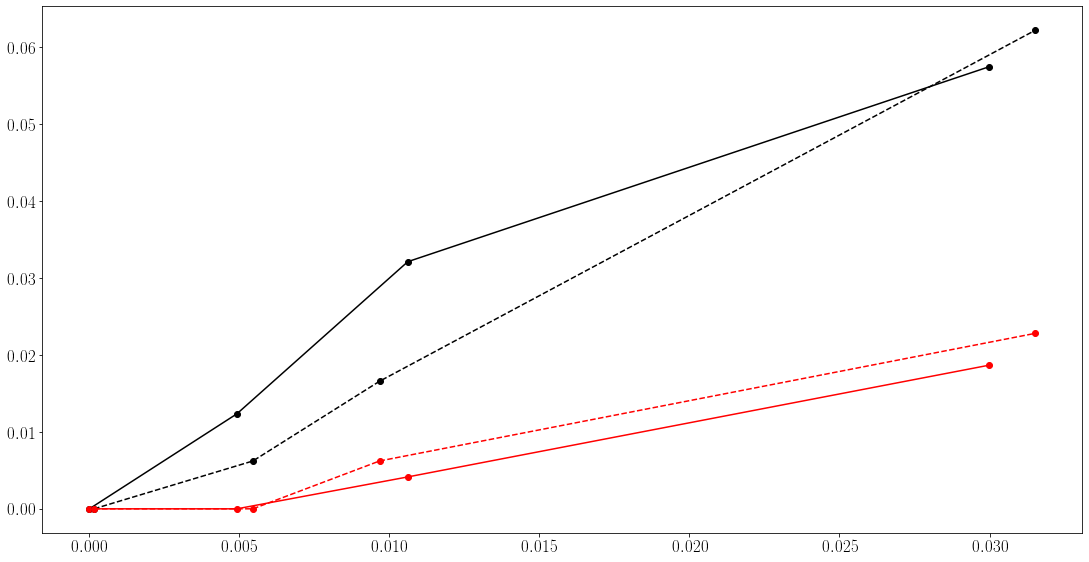

In [99]:
# Heating dynamics
plt.plot(doping1[:,1],shift1[:,1]-shift1[0,1],"k-",marker="o",label="$\lambda/V$=7.0")
plt.plot(doping1[:,1],shiftT1[:,0]-shiftT1[0,0],"r-",marker="o",label="$\lambda/V$=7.0")

plt.plot(doping5[:,1],shift5[:,1]-shift5[0,1],"k--",marker="o",label="$\lambda/V$=7.0")
plt.plot(doping5[:,1],shiftT5[:,0]-shiftT5[0,0],"r--",marker="o",label="$\lambda/V$=7.0")

In [92]:
shift5[:,1]-shift5[0,1]

array([0.        , 0.0062216 , 0.01659093, 0.06221598])

In [94]:
shiftT5[:,0]-shiftT5[0,0]

array([0.        , 0.        , 0.0062216 , 0.02281253])

# Fig 2 - BEC regime

In [9]:
def anal_ret(G,dt,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow,dt)
    for indx in np.where(np.abs(steps-twindow-tslice)<5e-1)[0]:
        slicetrace=np.trace(G.ret[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral        
        return np.array([-freq,-Aw.imag/np.pi])

def plot_disper(folder,ax,color="w"):
    allfiles=glob.glob("{}/out_denk*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    eigen=np.zeros((len(allfiles),2))
    eff=np.zeros((len(allfiles),2))
    for [i,files] in enumerate(allfiles):
#         print(i,files)
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
        kpoints[i]=imp.parm.kk[0]
        eigen[i,:]=np.array([imp.hkeff_eigen.data[0,0,0],imp.hkeff_eigen.data[0,1,1]])
        eff[i,:]=np.array([imp.hkeff.data[0,0,0],imp.hkeff.data[0,1,1]])
    
    index=kpoints.argsort()
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-0.264)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-0.264)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-0.264)*0.33,ls="--",color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-0.264)*0.33,ls="--",color=color)

def plot_disperHF(folder,ax,color="w"):
    allfiles=glob.glob("{}/out_full_k*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    eigen=np.zeros((len(allfiles),2))
    eff=np.zeros((len(allfiles),2))
    for [i,files] in enumerate(allfiles):
#         print(i,files)
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
        kpoints[i]=imp.parm.kk[0]
        eigen[i,:]=np.array([imp.hkeff_eigen.data[0,0,0],imp.hkeff_eigen.data[0,1,1]])
        eff[i,:]=np.array([imp.hkeff.data[0,0,0],imp.hkeff.data[0,1,1]])
    
    index=kpoints.argsort()
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-0.264)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-0.264)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-0.264)*0.33,ls="--",color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-0.264)*0.33,ls="--",color=color)


def plot_Akw(folder,tslice,eta,ax):
    allfiles=glob.glob("{}/out_k*.out".format(folder))
    twindow=60.0
    # Set length
    imp = read_imp_h5file_slices(allfiles[0],["G","parm"])
    dt=imp.parm.h[0]
    lengthsec=anal_ret(imp.G,dt,tslice,twindow,eta).shape[1]
#     anal_les(imp.G,imp.parm.h[0],imp.parm.kk[0],tslice,twindow,eta).shape[1]
    ret=np.zeros((len(allfiles)*2-1,2,lengthsec))
    les=np.zeros((len(allfiles)*2-1,2,lengthsec))
    indxfiles=0
    kpoints=np.zeros(len(allfiles))
#     twindow=60.0
    for files in allfiles:
        #print('--> Loading:', files)
        imp = read_imp_h5file_slices(files,["G","parm"])
        t=np.arange(0,imp.parm.nt)*dt
        G = imp.G
        kpoints[indxfiles]=imp.parm.kk[0]
#         ret[indxfiles,:,:]=anal_les(G,dt,imp.parm.kk[0],tslice,twindow,eta)
        ret[indxfiles,:,:]=anal_ret(G,dt,tslice,twindow,eta)
        indxfiles+=1
    index=kpoints.argsort()
#     ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=5.0,vmin=1e-2, norm=colors.PowerNorm(gamma=0.6),cmap="terrain",aspect='auto')
    ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=15.0,vmin=0.0,cmap="terrain",aspect='auto')
#     ax.set_title("${}$".format(label))
    
    #axtmp = ax.twinx()
    #axtmp._sharex = ax
    #formatter = FuncFormatter(lambda x, pos: '{:0.2f}'.format(x*0.26))
    #axtmp.set_xlim(ax.get_xlim())
    
    
def shift(angle):
    for [i,ele] in enumerate(angle):
        if ele<-np.pi:
            angle[i]=angle[i]+2.0*np.pi
        else:
            continue
    return angle


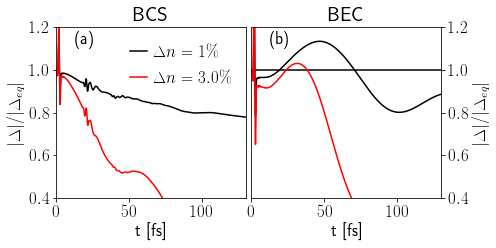

In [10]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.11
mpl.rcParams["figure.subplot.right"] = 0.9
mpl.rcParams["figure.subplot.bottom"] = 0.2
mpl.rcParams["figure.subplot.top"] = 0.9

ax0 = plt.subplot(1,2,1)
ax1 = plt.subplot(1,2,2)

#BCS
files="../abinitio/2bHYB/calc_U2.8_E00.22_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta17.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=1\%$")
np.savetxt("data/fig4_BCS_n1.txt",np.array([t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1])]).T)


files="../abinitio/2bHYB/calc_U2.8_E00.33_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta11.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=3.0\%$")
np.savetxt("data/fig4_BCS_n3.txt",np.array([t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1])]).T)

# files="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k")


# files="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.4_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r")

# files="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.45_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r--")


# files="../abinitio/2bHYB/calc_U2.8_E00.25_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.55_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g--")

files="../abinitio/2bHYB/calc_U2.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.55_t00.0_migdal1_nt4000_mu0.284127547569_beta30.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk512_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-")
np.savetxt("data/fig4_BEC_n1.txt",np.array([t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1])]).T)


files="../abinitio/2bHYB/calc_U2.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.55_t00.0_migdal1_nt4000_mu0.284127547569_beta30.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk512_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-")
np.savetxt("data/fig4_BEC_n3.txt",np.array([t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1])]).T)


ax1.hlines(1.0,0,t[-1]*time)

plt.subplots_adjust(wspace = 0.03,hspace=0.03)

ax0.set_ylim(0.4,1.2)
ax1.set_ylim(0.4,1.2)

ax0.set_xlim(0,130)
ax1.set_xlim(0,130)

ax0.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")

ax1.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()

ax0.legend(loc=1,frameon=False,handlelength=1,handletextpad=0.3)

ax0.text(0.1,0.9,"(a)",transform=ax0.transAxes)
ax1.text(0.1,0.9,"(b)",transform=ax1.transAxes)

ax0.set_xlabel("t~[fs]")
ax1.set_xlabel("t~[fs]")


ax0.set_title("BCS")
ax1.set_title("BEC")

plt.savefig("fin/fig4.pdf")

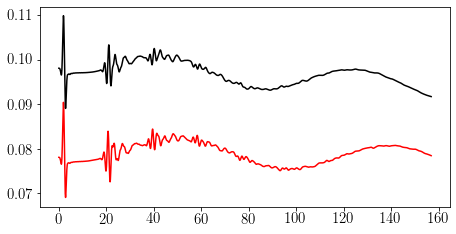

In [94]:
files="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.55_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
plt.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r")


files="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.45_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
plt.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"k")

# SM

IndexError: too many indices for array

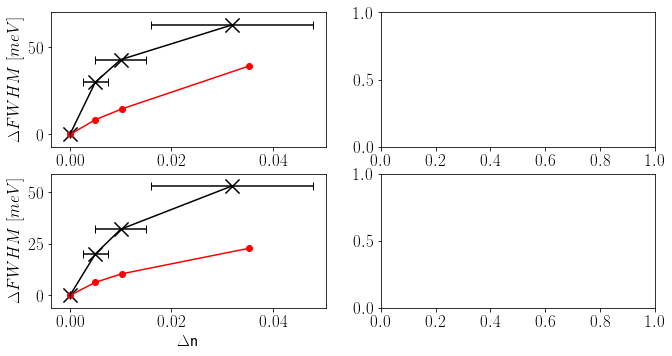

In [123]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2,8.6*4
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.13
mpl.rcParams["figure.subplot.top"] = 0.95


fig, ax = plt.subplots(2,2,figsize=(10,5))

# k=0.08

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow

bath=False

doping1=np.loadtxt("doping_U2.8.txt")
shift1=np.loadtxt("shifts_U2.8.txt")
shiftT1=np.loadtxt("shiftT_U2.8.txt")

# dopingT2=np.loadtxt("doping_U1.8.txt")
# shiftT2=np.loadtxt("shifts_U1.8.txt")

# dopingT3=np.loadtxt("doping_U1.0.txt")
# shiftT3=np.loadtxt("shifts_U1.0.txt")

#dopingT4=np.loadtxt("doping_U0.2.txt")
#shiftT4=np.loadtxt("shifts_U0.2.txt")

# dopingT5=np.loadtxt("doping_U0.0.txt")
# shiftT5=np.loadtxt("shifts_U0.0.txt")


ax[0,0].plot(doping1[:,1],(shift1[:,6]-shift1[0,6])*1000,"r-",marker="o",label="$\lambda/V$=0.03")
# ax[0,0].plot(dopingT2[:,1],(shiftT2[:,6]-shiftT2[0,6])*1000,"g-",marker="o",label="$\lambda/V$=0.05")
# ax[0,0].plot(dopingT3[:,1],(shiftT3[:,6]-shiftT3[0,6])*1000,"b-",marker="o",label="$\lambda/V$=0.5")
# ax[0,0].plot(doping4[:,1],np.abs(shift4[:,6]-shift4[0,6])*1000,"m-",marker="o",label="$\lambda/V$=7.0")


ax[1,0].plot(doping1[:,1],(shift1[:,9]-shift1[0,9])*1000,"r-",marker="o",label="$\lambda/V$=0.03")
# ax[1,0].plot(dopingT2[:,1],(shiftT2[:,9]-shiftT2[0,9])*1000,"g-",marker="o",label="$\lambda/V$=0.05")
# ax[1,0].plot(dopingT3[:,1],(shiftT3[:,9]-shiftT3[0,9])*1000,"b-",marker="o",label="$\lambda/V$=0.5")
# ax[1,0].plot(doping4[:,1],np.abs(shift4[:,9]-shift4[0,9])*1000,"m-",marker="o",label="$\lambda/V$=7.0")

# E peak[k=0] width FWHM peak[k=0.08] width FWHM peak[k=0.15] width FWHM


ax[0,0].set_xlabel("$\Delta$n")
ax[0,0].set_ylabel("$\Delta FWHM~[meV]$")

ax[1,0].set_xlabel("$\Delta$n")
ax[1,0].set_ylabel("$\Delta FWHM~[meV]$")

fluence=np.array([0,0.005,0.01,0.032])
shiftE0=np.array([0,30,45,65])
shiftE1=np.array([0,30,43,63])
shiftE2=np.array([0,20,32,53])

ax[0,0].errorbar(fluence,shiftE1,xerr=fluence*0.5,capsize=4,color="k",label="Exp")
ax[0,0].scatter(fluence,shiftE1,s = 200, marker = "x", color = "k")

ax[1,0].errorbar(fluence,shiftE2,xerr=fluence*0.5,capsize=4,color="k",label="Exp")
ax[1,0].scatter(fluence,shiftE2,s = 200, marker = "x", color = "k")

ax[0,1].plot(doping1[:,1],(shift1[:,4]-shiftT1[:,4]-(shift1[0,4]-shiftT1[0,4]))*1000,"r-",marker="o",label="$\lambda/V$=0.0")
# ax[0,1].plot(dopingT2[:,1],(shiftT2[:,4]-shiftT2[0,4])*1000,"g-",marker="o",label="$\lambda/V$=0.05")
# ax[0,1].plot(dopingT3[:,1],(shiftT3[:,4]-shiftT3[0,4])*1000,"b-",marker="o",label="$\lambda/V$=0.5")
# ax[0,1].plot(dopingT4[:,1],(shiftT4[:,4]-shiftT4[0,4])*1000,"m-",marker="o",label="$\lambda/V$=1.5")


# ax[1,1].plot(dopingT1[:,1],(shiftT1[:,7]-shiftT1[0,7])*1000,"r-",marker="o",label="$\lambda/V$=0.0")
# ax[1,1].plot(dopingT2[:,1],(shiftT2[:,7]-shiftT2[0,7])*1000,"g-",marker="o",label="$\lambda/V$=0.05")
# ax[1,1].plot(dopingT3[:,1],(shiftT3[:,7]-shiftT3[0,7])*1000,"b-",marker="o",label="$\lambda/V$=0.5")
ax[1,1].plot(dopingT4[:,1],(shiftT4[:,7]-shiftT4[0,7])*1000,"m-",marker="o",label="$\lambda/V$=1.5")


fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
# ax0.errorbar(fluence,shift,"k-",lw=2,xerr=0.01,label="Exp")
ax[0,1].errorbar(fluence,shift,xerr=fluence*0.5,color="k",marker="x",capsize=4,lw=2,label="Exp")
ax[0,1].scatter(fluence, shift, s = 200, marker = "x", color = "k")

ax[1,1].errorbar(fluence,shift,xerr=fluence*0.5,color="k",marker="x",capsize=4,lw=2,label="Exp")
ax[1,1].scatter(fluence, shift, s = 200, marker = "x", color = "k")


ax[0,1].set_ylabel("$d\mu~[meV]$")
ax[0,1].set_xlabel("$\Delta$n")
ax[0,1].set_ylabel("$\Delta E_0~[meV]$")


ax[1,1].set_ylabel("$d\mu~[meV]$")
ax[1,1].set_xlabel("$\Delta$n")
ax[1,1].set_ylabel("$\Delta E_0~[meV]$")

ax[0,1].yaxis.set_label_position("right")
ax[0,1].yaxis.tick_right()
ax[1,1].yaxis.set_label_position("right")
ax[1,1].yaxis.tick_right()


plt.subplots_adjust(wspace=0.01)

ax[0,0].set_ylim(0,50)
ax[0,0].set_xlim(0,0.08)
ax[0,1].set_xlim(0,0.08)
ax[1,0].set_xlim(0,0.08)
ax[1,1].set_xlim(0,0.08)

ax[1,1].legend()

ax[0,0].text(0.9,0.85,"(a)",transform=ax[0,0].transAxes)
ax[0,1].text(0.03,0.85,"(b)",transform=ax[0,1].transAxes)
ax[1,0].text(0.9,0.85,"(c)",transform=ax[1,0].transAxes)
ax[1,1].text(0.03,0.85,"(d)",transform=ax[1,1].transAxes)


ax[0,0].get_xaxis().set_ticklabels([])
ax[0,1].get_xaxis().set_ticklabels([])

plt.subplots_adjust(wspace = 0.03,hspace=0.03)

plt.savefig("fin/figSM.svg")

In [49]:
def anal_ret(G,dt,tslice,twindow,eta):
    steps=G.steps*dt
    time=np.arange(0,twindow,dt)
    for indx in np.where(np.abs(steps-twindow-tslice)<5e-1)[0]:
        slicetrace=np.trace(G.ret[indx,G.steps[indx]-int(twindow/dt):G.steps[indx]],axis1=1,axis2=2)*np.exp(-eta*time[::-1])
        freq, Aw=get_ft(-slicetrace[::-1].conj(),dt,True,True,10) #reverse direction, due to definition of integral        
        return np.array([-freq,-Aw.imag/np.pi])

def plot_disper(folder,ax,color="w"):
    allfiles=glob.glob("{}/out_denk*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    eigen=np.zeros((len(allfiles),2))
    eff=np.zeros((len(allfiles),2))
    for [i,files] in enumerate(allfiles):
#         print(i,files)
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
        kpoints[i]=imp.parm.kk[0]
        eigen[i,:]=np.array([imp.hkeff_eigen.data[-1,0,0],imp.hkeff_eigen.data[-1,1,1]])
        eff[i,:]=np.array([imp.hkeff.data[-1,0,0],imp.hkeff.data[-1,1,1]])
    
    index=kpoints.argsort()
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-0.264)*0.33,color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-0.264)*0.33,color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-0.284)*0.33,ls="--",color=color)
    ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-0.284)*0.33,ls="--",color=color)
    
#     for [i,files] in enumerate(allfiles):
#         imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
#         kpoints[i]=imp.parm.kk[0]
#         eigen[i,:]=np.array([imp.hkeff_eigen.data[0,0,0],imp.hkeff_eigen.data[0,1,1]])
#         eff[i,:]=np.array([imp.hkeff.data[0,0,0],imp.hkeff.data[0,1,1]])
    
#     index=kpoints.argsort()
# #     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-0.264)*0.33,lw=2,color=color)
# #     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-0.264)*0.33,lw=2,color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-0.264)*0.33,ls="--",lw=2,color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-0.264)*0.33,ls="--",lw=2,color=color)

def plot_disperHF(folder,ax,color="w"):
    allfiles=glob.glob("{}/out_full_k*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    eigen=np.zeros((len(allfiles),2))
    eff=np.zeros((len(allfiles),2))
    for [i,files] in enumerate(allfiles):
#         print(i,files)
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm"])
        kpoints[i]=imp.parm.kk[0]
        eigen[i,:]=np.array([imp.hkeff_eigen.data[0,0,0],imp.hkeff_eigen.data[0,1,1]])
        eff[i,:]=np.array([imp.hkeff.data[0,0,0],imp.hkeff.data[0,1,1]])
    
    index=kpoints.argsort()
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,0]-0.264)*0.33,color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eigen[index,1]-0.264)*0.33,color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,0]-0.264)*0.33,ls="--",color=color)
#     ax.plot((kpoints[index]+np.pi/64.0)/3.5,(eff[index,1]-0.264)*0.33,ls="--",color=color)


def plot_Akw(folder,tslice,eta,ax):
    allfiles=glob.glob("{}/out_k*.out".format(folder))
    twindow=60.0
    # Set length
    imp = read_imp_h5file_slices(allfiles[0],["G","parm"])
    dt=imp.parm.h[0]
    lengthsec=anal_ret(imp.G,dt,tslice,twindow,eta).shape[1]
#     anal_les(imp.G,imp.parm.h[0],imp.parm.kk[0],tslice,twindow,eta).shape[1]
    ret=np.zeros((len(allfiles)*2-1,2,lengthsec))
    les=np.zeros((len(allfiles)*2-1,2,lengthsec))
    indxfiles=0
    kpoints=np.zeros(len(allfiles))
#     twindow=60.0
    for files in allfiles:
        #print('--> Loading:', files)
        imp = read_imp_h5file_slices(files,["G","parm"])
        t=np.arange(0,imp.parm.nt)*dt
        G = imp.G
        kpoints[indxfiles]=imp.parm.kk[0]
#         ret[indxfiles,:,:]=anal_les(G,dt,imp.parm.kk[0],tslice,twindow,eta)
        ret[indxfiles,:,:]=anal_ret(G,dt,tslice,twindow,eta)
        indxfiles+=1
    index=kpoints.argsort()
#     ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=5.0,vmin=1e-2, norm=colors.PowerNorm(gamma=0.6),cmap="terrain",aspect='auto')
    ax.imshow(np.transpose(ret[index,1,:]),extent=(-np.pi/3.5,np.pi/3.5,(-ret[0,0,0])*hop,(ret[0,0,0])*hop),interpolation="spline16",origin='lower',vmax=10.0,vmin=0.0,cmap="terrain",aspect='auto')
#     ax.set_title("${}$".format(label))
    
    #axtmp = ax.twinx()
    #axtmp._sharex = ax
    #formatter = FuncFormatter(lambda x, pos: '{:0.2f}'.format(x*0.26))
    #axtmp.set_xlim(ax.get_xlim())
    
    
def shift(angle):
    for [i,ele] in enumerate(angle):
        if ele<-np.pi:
            angle[i]=angle[i]+2.0*np.pi
        else:
            continue
    return angle


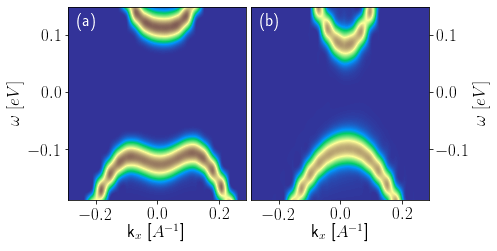

In [51]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.13
mpl.rcParams["figure.subplot.right"] = 0.87
mpl.rcParams["figure.subplot.bottom"] = 0.18
mpl.rcParams["figure.subplot.top"] = 0.97

ax0 = plt.subplot(1,2,1)
ax1 = plt.subplot(1,2,2)


folder="../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
# plot_disper(folder,ax=ax0,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax0)

folder="../abinitio/2bHYB/calc_U2.8_E00.15_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.5_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116//output/"
# plot_disper(folder,ax=ax1,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax1)



ax0.set_ylabel("$\omega~[eV]$")
ax1.set_ylabel("$\omega~[eV]$")

ax0.set_xlabel("k$_x$~[$A^{-1}$]")
ax1.set_xlabel("k$_x$~[$A^{-1}$]")
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()

ax0.set_xlim(-0.29,0.29)
ax1.set_xlim(-0.29,0.29)

ax0.set_ylim(-0.19,0.15)
ax1.set_ylim(-0.19,0.15)

ax0.text(0.05,0.9,"(a)",transform=ax0.transAxes,color="w")
ax1.text(0.05,0.9,"(b)",transform=ax1.transAxes,color="w")

plt.subplots_adjust(wspace = 0.03,hspace=0.03)
plt.savefig("fin/figSM2.pdf")

/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.


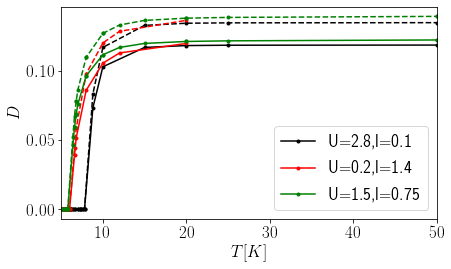

In [4]:
def sumk(folder):
#     print(folder)
    allfiles=glob.glob("{}/out_denk*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    rho=np.zeros(len(allfiles))
    for [i,files] in enumerate(allfiles):
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm","rho"])
        kpoints[i]=imp.parm.kk[0]
        rho[i]=imp.rho.data[0,0,1]
    index=kpoints.argsort()
    k=(kpoints[index]+np.pi/64.0)

    return np.sum(np.real(rho[index])*np.cos(k/2))/len(kpoints)

%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.13
mpl.rcParams["figure.subplot.right"] = 0.9
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.97

ax0 = plt.subplot(1,1,1)

files=glob.glob("../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.284127547569_beta*_ntau2000_dt0.02_err*_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(order1[indx,0],order1[indx,1],"k-",marker=".",label="U=2.8,l=0.1")
ax0.plot(order1[indx,0],order1[indx,2],"k--",marker=".")


files=glob.glob("../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.284127547569_beta*_ntau2000_dt0.02_err*_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(order1[indx,0],order1[indx,1],"r-",marker=".",label="U=0.2,l=1.4")
ax0.plot(order1[indx,0],order1[indx,2],"r--",marker=".")


files=glob.glob("../abinitio/2bHYB/calc_U1.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.283564772347_beta*_ntau2000_dt0.02_err*_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(order1[indx,0],order1[indx,1],"g-",marker=".",label="U=1.5,l=0.75")
ax0.plot(order1[indx,0],order1[indx,2],"g--",marker=".")

ax0.set_xlim(5,50)
ax0.set_xlabel("$T [K]$")
ax0.set_ylabel("$D$")
plt.legend()

plt.subplots_adjust(wspace = 0.03,hspace=0.03)

/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  # Remove the CWD from sys.path while we load stuff.
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: divide by zero encountered in true_divide
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in true_divide
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:55: RuntimeWarning: divide by zero encountered in true_divide
/cm/shared/sw/pkg/devel/python3/3.7.3/lib/python3.7/site-packages/ipykernel_launcher.py:69: RuntimeWarning: divide by zero encountered in true_divide
/cm/shared/sw/pkg/devel/pytho

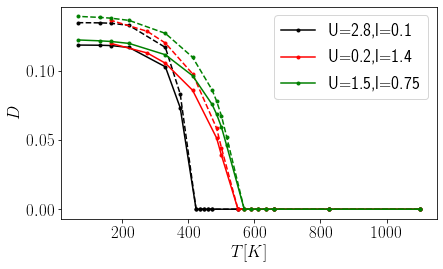

In [100]:
def sumk(folder):
#     print(folder)
    allfiles=glob.glob("{}/out_denk*.out".format(folder))
    # Set length
    kpoints=np.zeros(len(allfiles))
    rho=np.zeros(len(allfiles))
    for [i,files] in enumerate(allfiles):
        imp = read_imp_h5file_slices(files,["hkeff","hkeff_eigen","parm","rho"])
        kpoints[i]=imp.parm.kk[0]
        rho[i]=imp.rho.data[0,0,1]
    index=kpoints.argsort()
    k=(kpoints[index]+np.pi/64.0)

    return np.sum(np.real(rho[index])*np.cos(k/2))/len(kpoints)

%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.13
mpl.rcParams["figure.subplot.right"] = 0.9
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.97

ax0 = plt.subplot(1,1,1)

files=glob.glob("../abinitio/2bHYB/calc_U2.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.284127547569_beta*_ntau2000_dt0.02_err3e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(3300/order1[indx,0],order1[indx,1],"k-",marker=".",label="U=2.8,l=0.1")
ax0.plot(3300/order1[indx,0],order1[indx,2],"k--",marker=".")


files=glob.glob("../abinitio/2bHYB/calc_U0.2_E00.0_om6.0_om00.05_lam1.4_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.284127547569_beta*_ntau2000_dt0.02_err3e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(3300/order1[indx,0],order1[indx,1],"r-",marker=".",label="U=0.2,l=1.4")
ax0.plot(3300/order1[indx,0],order1[indx,2],"r--",marker=".")


files=glob.glob("../abinitio/2bHYB/calc_U1.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt10_mu0.283564772347_beta*_ntau2000_dt0.02_err3e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116")
order1=np.zeros((len(files),3))

for [i,file] in enumerate(files):
    try:
        imp = read_imp_h5file(file+"/output/out_full_local.out",["obs","parm"])
        order1[i,:]=np.array([imp.parm.beta[0],sumk(file+"/output/"),np.real(imp.obs.rho_loc.data[0,0,1])])
    except:
        continue

indx=np.argsort(order1[:,0])
ax0.plot(3300/order1[indx,0],order1[indx,1],"g-",marker=".",label="U=1.5,l=0.75")
ax0.plot(3300/order1[indx,0],order1[indx,2],"g--",marker=".")

# ax0.set_xlim(1,30)
ax0.set_xlabel("$T [K]$")
ax0.set_ylabel("$D$")
plt.legend()
plt.subplots_adjust(wspace = 0.03,hspace=0.03)
plt.savefig("fin/order.pdf")

In [55]:
# Effective temperatures
print(3300/20,3300/15,3300/10)

print(3300/50,3300/20,3300/13)


165.0 220.0 330.0
66.0 165.0 253.84615384615384


In [105]:
# Electron driven
Tc=327
exp=np.array([90,115,219])
exp1=np.array([165,270])
exp2=np.array([90,170])

betaCT=6.0
print(betaCT*Tc/exp)
print(betaCT*Tc/exp1)
print(betaCT*Tc/exp2)

[21.8        17.06086957  8.95890411]
[11.89090909  7.26666667]
[21.8        11.54117647]


In [107]:
# Phonon driven
Tc=327
exp=np.array([90,115,219])
exp1=np.array([165,270])
exp2=np.array([90,170])

betaCT=5.0
print(betaCT*Tc/exp)
print(betaCT*Tc/exp1)
print(betaCT*Tc/exp2)

[18.16666667 14.2173913   7.46575342]
[9.90909091 6.05555556]
[18.16666667  9.61764706]


# backup

In [ ]:
# %matplotlib inline
mpl.rcParams['font.size'] = 20
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


ome = np.linspace(-0.4,0.1,100)
kpoints=np.array([32,29,26])
twindow=50.0

fig, ax = plt.subplots(3, 3,figsize=(10,10))

# Experiment
energy=np.loadtxt("expVancouver/Energy.txt")
datak0_E26=np.loadtxt("expVancouver/EDC_k0_25uJ.txt")
datak0_E50=np.loadtxt("expVancouver/EDC_k0_50uJNEW.txt")
datak0_E160=np.loadtxt("expVancouver/EDC_k0_160uJ.txt")

ax[0,0].plot(energy,datak0_E26[0,:],"k--")
ax[0,0].plot(energy,datak0_E26[-1,:],"r-")
ax[0,0].plot(energy,datak0_E50[-1,:],"b-")
ax[0,0].plot(energy,datak0_E160[-1,:],"m-")

datak08_E26=np.loadtxt("expVancouver/EDC_k08_26uJ.txt")
datak08_E50=np.loadtxt("expVancouver/EDC_k08_50uJ.txt")
datak08_E160=np.loadtxt("expVancouver/EDC_k08_160uJ.txt")

ax[0,1].plot(energy,datak08_E26[0,:],"k--")
ax[0,1].plot(energy,datak08_E26[-1,:],"r-")
ax[0,1].plot(energy,datak08_E50[-1,:],"b-")
ax[0,1].plot(energy,datak08_E160[-1,:],"m-")


datak15_E26=np.loadtxt("expVancouver/EDC_k15_26uJ.txt")
datak15_E50=np.loadtxt("expVancouver/EDC_k15_50uJ.txt")
datak15_E160=np.loadtxt("expVancouver/EDC_k15_160uJ.txt")

ax[0,2].plot(energy,datak15_E26[0,:],"k--",label="Eq")
ax[0,2].plot(energy,datak15_E26[-1,:],"r-",label="0.5\%")
ax[0,2].plot(energy,datak15_E50[-1,:],"b-",label="1\%")
ax[0,2].plot(energy,datak15_E160[-1,:],"m-",label="3.5\%")

for [indxk,k] in enumerate(kpoints):
    file="../abinitio/2bNEW/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[1,indxk].plot((ome+0.01047546)*0.33,Nw,"k--",lw=2)
    omP=np.flip((ome+0.01047546)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U18_n0_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    
    # dn=0.5 %
    file="../abinitio/2bNEW/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome+0.01047546)*0.33,Nw,"r-",lw=2)
    omP=np.flip((ome+0.01047546)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U18_n05_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    
    # dn=1 %
    file="../abinitio/2bNEW/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome-0.02)*0.33,Nw,"b-",lw=2)
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U18_n1_k{}.txt".format(indxk),np.array([omP,NwP]).T)    

    # dn=3.5 %
    file="../abinitio/2bNEW/calc_U1.8_E00.6_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[1,indxk].plot((ome-0.02)*0.33,Nw,"m-",lw=2)
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U18_n35_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    
# Lattice    
for [indxk,k] in enumerate(kpoints):
#     file="../abinitio/2bNEW/calc_U0.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347469_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
#     [ome,Nw]=get_kslice(file,10.0,twindow)
#     ax[2,indxk].plot((ome-0.06809053)*0.33,Nw,"k--",lw=2,label="Eq")
    file="../abinitio/2bNEW/calc_U0.5_E00.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347469_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[2,indxk].plot((ome-0.02)*0.33,Nw,"k--",lw=2,label="Eq")
#     file="../abinitio/2bHYB/calc_U0.5_E00.0_om6.0_om00.05_lam1.25_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta50.0_ntau2000_dt0.02_err1e-05_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_k{}.out".format(k)
#     [ome,Nw]=get_kslice(file,0.0,twindow)
#     ax[2,indxk].plot((ome-0.02)*0.33,Nw,"k-.",lw=2,label="Eq")
    
    [x,y]=get_range((ome-0.02)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U05_n0_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    # 0.5 %
    file="../abinitio/2bNEW/calc_U0.5_E00.4_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347469_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116//output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome-0.02)*0.33,Nw,"r-",lw=2,label="Eq")
    [x,y]=get_range((ome-0.02)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U05_n05_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    # 1.0 %
    file="../abinitio/2bNEW/calc_U0.5_E00.6_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347469_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116//output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome-0.02)*0.33,Nw,"b-",lw=2,label="Eq")
    [x,y]=get_range((ome-0.02)*0.33,Nw,-2,0)
    print(simps(y,x))
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U05_n1_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    # 3.5 %
    file="../abinitio/2bNEW/calc_U0.5_E01.0_om6.0_om00.05_lam0.75_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.283564772347469_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116//output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,30.0,twindow)
    ax[2,indxk].plot((ome-0.02)*0.33,Nw,"m-",lw=2,label="Eq")
    [x,y]=get_range((ome-0.02)*0.33,Nw,-2,0)
    omP=np.flip((ome-0.02)*0.33)
    NwP=np.flip(Nw)
    np.savetxt("data/fig3_U05_n35_k{}.txt".format(indxk),np.array([omP,NwP]).T)
    print(simps(y,x))
    print("-------")
    
ax[0,0].set_xlim(-0.3,0.05)
ax[0,1].set_xlim(-0.3,0.05)
ax[0,2].set_xlim(-0.3,0.05)

ax[1,0].set_xlim(-0.3,0.05)
ax[1,1].set_xlim(-0.3,0.05)
ax[1,2].set_xlim(-0.3,0.05)

ax[2,0].set_xlim(-0.3,0.3)
ax[2,1].set_xlim(-0.3,0.3)
ax[2,2].set_xlim(-0.3,0.3)

ax[0,0].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[0,1].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[0,2].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))


ax[1,0].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[1,1].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[1,2].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))



ax[2,0].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[2,1].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))
ax[2,2].set_xticks(np.array([-0.3,-0.2,-0.1,0.0]))

#Set x-axis
ax[0,0].get_xaxis().set_ticklabels([])
ax[0,1].get_xaxis().set_ticklabels([])
ax[0,2].get_xaxis().set_ticklabels([])
ax[1,0].get_xaxis().set_ticklabels([])
ax[1,1].get_xaxis().set_ticklabels([])
ax[1,2].get_xaxis().set_ticklabels([])
#Set y-axis
ax[0,1].get_yaxis().set_ticklabels([])
ax[0,2].get_yaxis().set_ticklabels([])
ax[1,1].get_yaxis().set_ticklabels([])
ax[1,2].get_yaxis().set_ticklabels([])
ax[2,1].get_yaxis().set_ticklabels([])
ax[2,2].get_yaxis().set_ticklabels([])


ax[0,0].set_title("k$_x$=0 A$^{-1}$")
ax[0,1].set_title("k$_x$=0.08 A$^{-1}$")
ax[0,2].set_title("k$_x$=0.15 A$^{-1}$")
ax[0,0].text(0.05,0.9,"(a)",transform=ax[0,0].transAxes)
ax[0,1].text(0.05,0.9,"(b)",transform=ax[0,1].transAxes)
ax[0,2].text(0.05,0.9,"(c)",transform=ax[0,2].transAxes)


ax[0,0].set_ylabel("I($\omega$,k)")
ax[1,0].set_ylabel("I($\omega$,k)")
ax[2,0].set_ylabel("I($\omega$,k)")
ax[1,0].text(0.05,0.9,"(d)",transform=ax[1,0].transAxes)
ax[1,1].text(0.05,0.9,"(e)",transform=ax[1,1].transAxes)
ax[1,2].text(0.05,0.9,"(f)",transform=ax[1,2].transAxes)


ax[2,0].set_xlabel("$\omega~[eV]$")
ax[2,1].set_xlabel("$\omega~[eV]$")
ax[2,2].set_xlabel("$\omega~[eV]$")
ax[2,0].text(0.05,0.9,"(g)",transform=ax[2,0].transAxes)
ax[2,1].text(0.05,0.9,"(h)",transform=ax[2,1].transAxes)
ax[2,2].text(0.05,0.9,"(i)",transform=ax[2,2].transAxes)

# ax[0,0].legend(loc=1,frameon=False,handlelength=1,handletextpad=0.1)
# ax[1,0].legend(loc=1,frameon=False,handlelength=1,handletextpad=0.1)
ax[0,2].legend(loc=1,frameon=False,handlelength=1,handletextpad=0.3)

plt.subplots_adjust(wspace = 0.03,hspace=0.03)
# plt.savefig("fin/fig3.svg")

In [ ]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6*2/2.54
mpl.rcParams["figure.subplot.left"] = 0.13
mpl.rcParams["figure.subplot.right"] = 0.9
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.97

ax0 = plt.subplot(2,2,1)
ax1 = plt.subplot(2,2,2)

ax2 = plt.subplot(2,2,3)
ax3 = plt.subplot(2,2,4)

folder="../abinitio/2bNEW/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/"
# plot_disper(folder,ax=ax0,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax0)

folder="../abinitio/2bNEW/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/"
# plot_disper(folder,ax=ax0,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax2)

#BCS
files="../abinitio/2bNEW/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=1\%$")


files="../abinitio/2bNEW/calc_U1.8_E00.6_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=3.5\%$")


#BEC
# Delta =1.3

# files="../abinitio/2bNEW/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g")

files="../abinitio/2bNEW/calc_U1.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k")

files="../abinitio/2bNEW/calc_U1.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--")

files="../abinitio/2bNEW/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r")

files="../abinitio/2bNEW/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r--")


ax0.set_ylabel("$\epsilon_k$")
ax2.set_ylabel("$\epsilon_k$")

ax0.get_xaxis().set_ticklabels([])
ax0.xaxis.tick_top()
ax1.get_xaxis().set_ticklabels([])

plt.subplots_adjust(wspace = 0.03,hspace=0.03)

ax0.set_xlim(-0.29,0.29)
ax2.set_xlim(-0.29,0.29)

ax0.set_ylim(-0.19,0.15)
ax2.set_ylim(-0.19,0.15)

ax1.set_ylim(0.6,1.15)
ax3.set_ylim(0.6,1.15)

# ax1.set_xlim(0.0,50)
# ax3.set_xlim(0.0,50)

ax1.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()

ax3.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()

ax1.legend(frameon=False,handlelength=1,handletextpad=0.3)
ax3.legend(frameon=False,handlelength=1,handletextpad=0.3)

ax0.text(0.05,0.9,"(a)",transform=ax0.transAxes,color="w")
ax1.text(0.07,0.9,"(b)",transform=ax1.transAxes)
ax2.text(0.05,0.9,"(c)",transform=ax2.transAxes,color="w")
ax3.text(0.07,0.9,"(d)",transform=ax3.transAxes)

# ax0.set_xlabel("k$_x$~[$A^{-1}$]")
ax2.set_xlabel("k$_x$~[$A^{-1}$]")
ax3.set_xlabel("t~[fs]")

plt.savefig("fin/fig4old.svg")

In [ ]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6*3/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(3,2,1)
ax1 = plt.subplot(3,2,2)

ax2 = plt.subplot(3,2,3)
ax3 = plt.subplot(3,2,4)

ax4 = plt.subplot(3,2,5)
ax5 = plt.subplot(3,2,6)

folder="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/"
plot_disper(folder,ax=ax0,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax0)

folder="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/"
plot_disper(folder,ax=ax2,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax2)


folder="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/"
plot_disper(folder,ax=ax4,color="w")
plot_Akw(folder,tslice=0.0,eta=0.0,ax=ax4)


# Delta =1.3
files="../abinitio/2b/calc_U1.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=0.04$")


files="../abinitio/2b/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g-",label="$\Delta n=0.05$")

# Delta =1.3 mazza=0.05
files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g--",label="$\Delta n=0.0$")


files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")


# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r--",label="$\Delta n=0.04$")


# Delta =1.2
files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=0.03$")

files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g-",label="$\Delta n=0.04$")

files="../abinitio/2b/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"b-",label="$\Delta n=0.05$")


# files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.04$")


# # Delta =1.1
files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax5.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=0.02?$")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax5.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.04 ?$")






ax0.set_ylabel("$\epsilon_k$")
ax2.set_ylabel("$\epsilon_k$")
ax4.set_ylabel("$\epsilon_k$")

ax0.get_xaxis().set_ticklabels([])
ax2.get_xaxis().set_ticklabels([])

plt.subplots_adjust(wspace = 0.03,hspace=0.03)



ax0.set_xlim(-0.29,0.29)
ax2.set_xlim(-0.29,0.29)
ax4.set_xlim(-0.29,0.29)

ax0.set_ylim(-0.19,0.1)
ax2.set_ylim(-0.19,0.1)
ax4.set_ylim(-0.19,0.1)

ax1.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax1.yaxis.set_label_position("right")
ax1.yaxis.tick_right()

ax3.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax3.yaxis.set_label_position("right")
ax3.yaxis.tick_right()

ax5.set_ylabel("$|\Delta|$/$|\Delta_{eq}|$")
ax5.yaxis.set_label_position("right")
ax5.yaxis.tick_right()


ax1.legend(frameon=False,handlelength=1,handletextpad=0.3)
ax3.legend(frameon=False,handlelength=1,handletextpad=0.3)
ax5.legend(frameon=False,handlelength=1,handletextpad=0.3)

ax0.text(0.05,0.9,"(a)",transform=ax0.transAxes,color="w")
ax1.text(0.08,0.9,"(b)",transform=ax1.transAxes)
ax2.text(0.05,0.9,"(c)",transform=ax2.transAxes,color="w")

ax3.text(0.08,0.9,"(d)",transform=ax3.transAxes)
ax4.text(0.05,0.9,"(e)",transform=ax4.transAxes,color="w")
ax5.text(0.08,0.9,"(f)",transform=ax5.transAxes)

ax4.set_xlabel("k~[$A^{-1}$]")
ax5.set_xlabel("t~[fs]")

plt.savefig("fin/fig4.svg")

No handles with labels found to put in legend.
No handles with labels found to put in legend.


(0.8, 1.2)

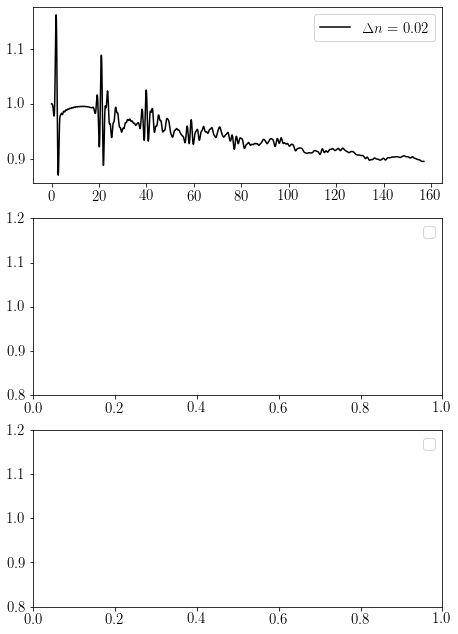

In [32]:
%matplotlib inline

mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6*3/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(3,1,1)
ax1 = plt.subplot(3,1,2)
ax2 = plt.subplot(3,1,3)


# Delta =1.3
files="../abinitio/2bNEW/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k",label="$\Delta n=0.02$")


# files="../abinitio/2bNEW/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.2662875663_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k",label="$\Delta n=0.02$")


# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r-",label="$\Delta n=0.04$")


# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk80_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r--",label="$\Delta n=0.04$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk100_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"k-",lw=2,label="$\Delta n=0.04$")



# # files="../abinitio/2b/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g-",label="$\Delta n=0.05$")





# # # Delta =1.3 mazza=0.05
# # files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g--",label="$\Delta n=0.0$")


# # files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")


# # files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r--",label="$\Delta n=0.04$")


# # Delta =1.2
# files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.02$")


# files="../abinitio/2b/calc_U1.8_E00.3_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=0.03$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g-",label="$\Delta n=0.04$")

# files="../abinitio/2b/calc_U1.8_E00.5_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"b-",label="$\Delta n=0.05$")


# # files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")

# # files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.2_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# # imp = read_imp_h5file(files,["obs","parm"])
# # dt=imp.parm.h[0]
# # t=np.arange(imp.parm.nt[0]+2)*dt
# # n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# # ax3.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.04$")


# # # Delta =1.1
# files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax2.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="$\Delta n=0.02?$")


# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax2.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="$\Delta n=0.04 ?$")


# files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax2.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r--",label="$\Delta n=0.02?$")


# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax2.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.04 ?$")


ax0.legend()
ax1.legend()
ax2.legend()
# 
# ax0.set_ylim(0.8,1.2)
ax1.set_ylim(0.8,1.2)
ax2.set_ylim(0.8,1.2)


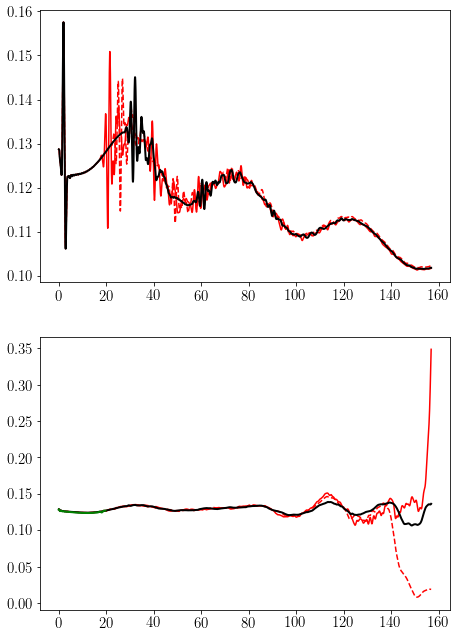

In [58]:
# finite size analysis
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6*3/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(2,1,1)
ax1 = plt.subplot(2,1,2)


#E=0.4


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r-",label="$\Delta n=0.04$")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk80_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r--",label="$\Delta n=0.04$")

files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk100_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"k-",lw=2,label="$\Delta n=0.04$")


#E=0.0

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r-",label="$\Delta n=0.04$")


files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk80_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r--",label="$\Delta n=0.04$")

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk100_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"k-",lw=2,label="$\Delta n=0.04$")


files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt500_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.0_omBATH1.0_nk60_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"g-",lw=2,label="$\Delta n=0.04$")



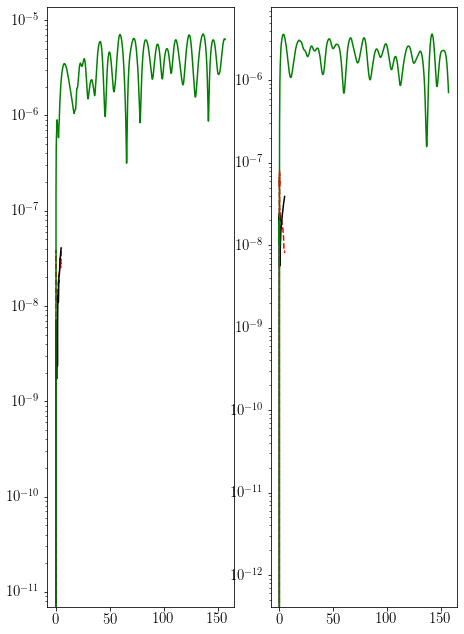

In [31]:
# check equilibrium propagation
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2/2.54,8.6*3/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(1,2,1)
ax1 = plt.subplot(1,2,2)



files="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/2bNEW/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt4000_mu0.284127547569083_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"g-",label="$\Delta n=0.02$")
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[0,0,0]),"g-",label="$\Delta n=0.02$")



# ax0.set_xlim(0,0.5)
# ax0.set_ylim(0,0.03)
ax0.set_yscale("log")

# ax1.set_xlim(0,0.5)
# ax0.set_ylim(0,0.03)
ax1.set_yscale("log")

In [85]:
folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/Dk_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0],label="Dk")

folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/Pph_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0],label="Pph")


folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/D0Pph_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0],label="D0Pph")


folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/PphD0_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0],label="PphD0")


plt.legend()

AttributeError: 'Dummy' object has no attribute 'G'

/mnt/home/dgolez/Projects/dmft/github/nessi/libcntr/python3/ReadCNTRhdf5.py:214: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  new_data[idx] = data


(0, -0.0001)

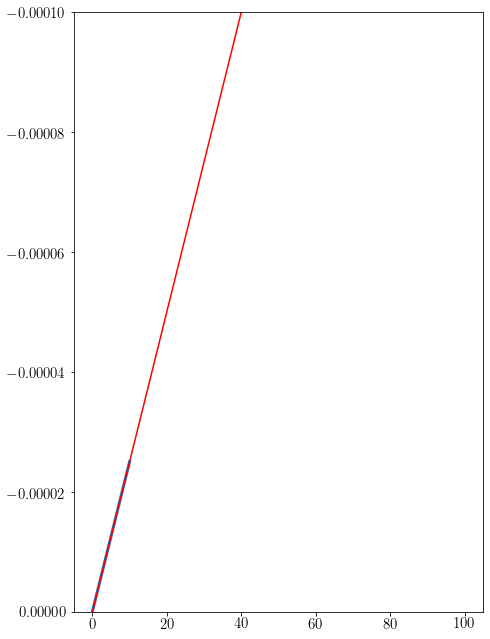

In [94]:
file="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/9a60248/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(file,["Dloc"])
plt.plot(imp.Dloc.ret[:,0,0,0].real,lw=3)

# imp = read_imp_h5file(file,["D0loc"])
# plt.plot(imp.D0loc.ret[:,0,0,0].real,"k-",lw=3)


file="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/1da9d14/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal0_nt100_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/output/out_full_local.out"
imp = read_imp_h5file(file,["Dloc"])
plt.plot(imp.Dloc.ret[:,0,0,0].real,"r-")

plt.ylim(0,-0.0001)


In [66]:
imp = read_imp_h5file(file,["Dloc"])

/mnt/home/dgolez/Projects/dmft/github/nessi/libcntr/python3/ReadCNTRhdf5.py:214: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  new_data[idx] = data


In [67]:
imp.Dloc.ret[:,0,0,0]

array([ 0.00000000e+00+0.00000000e+00j, -9.99999833e-04-9.11833008e-16j,
       -1.99999867e-03-1.42446327e-14j, -2.99999550e-03-6.85726389e-14j,
       -3.99998933e-03-2.01317722e-13j, -1.24999479e-05-1.11005623e-15j,
       -1.49999100e-05-2.01923450e-15j, -1.74998571e-05-3.28935082e-15j,
       -1.99997867e-05-4.50182970e-15j, -2.24996963e-05-5.85847420e-15j,
       -2.49995834e-05-6.09508108e-15j, -2.74994456e-05-5.26535745e-15j,
       -2.99992802e-05-1.58203116e-15j, -3.24990849e-05+5.87003010e-15j,
       -3.49988571e-05+1.89634714e-14j, -3.74985943e-05+3.97477610e-14j,
       -3.99982941e-05+7.05389159e-14j, -4.24979539e-05+1.14125872e-13j,
       -4.49975713e-05+1.73529664e-13j, -4.74971437e-05+2.52135007e-13j,
       -4.99966687e-05+3.53607965e-13j, -5.24961438e-05+4.81883039e-13j,
       -5.49955665e-05+6.41142378e-13j, -5.74949342e-05+8.35776269e-13j,
       -5.99942446e-05+1.07035441e-12j, -6.24934951e-05+1.34958937e-12j,
       -6.49926832e-05+1.67830002e-12j, -6.74918065

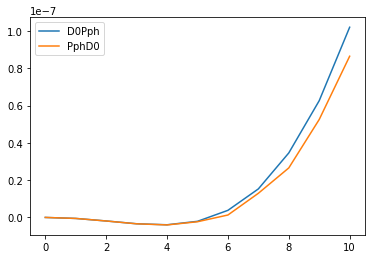

In [45]:
folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/D0Pph_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0].imag,label="D0Pph")


folder="/mnt/home/dgolez/ceph/Projects/results/exciton/semiconductor_phonons/2b/vancouver/abinitio/7fb359f/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt10_mu0.0_beta20.0_ntau1500_dt0.02_err1e-07_bath0.0_gBATH0.0_omBATH1.0_nk16_mazza0.116/PphD0_10_10_3_0.h5"
imp = read_imp_h5file(folder)
plt.plot(imp.G.ret[:,0,0,0].imag,label="PphD0")


plt.legend()

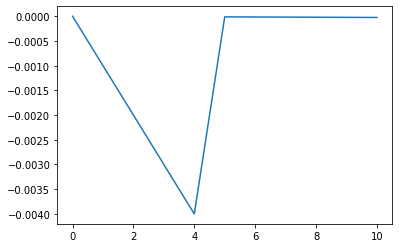

In [21]:
imp.G.ret[:,0,0,0]

array([-0.00000000e+00+0.00000000e+00j, -9.99999833e-04-9.18966643e-16j,
       -1.99999867e-03-1.39718865e-14j, -2.99999550e-03-6.54574345e-14j,
       -3.99998933e-03-1.83914245e-13j, -1.24999479e-05-9.45235858e-16j,
       -1.49999100e-05-1.53076848e-15j, -1.74998571e-05-2.06745386e-15j,
       -1.99997867e-05-1.80278080e-15j, -2.24996963e-05-4.42173873e-16j,
       -2.49995835e-05+3.98534409e-15j])

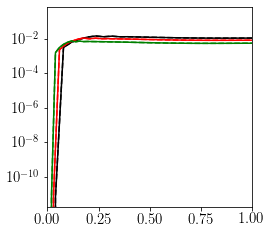

In [18]:
# convergence
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(1,1,1)




# Delta =1.3
files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"k",label="$\Delta n=0.02$")

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"r",label="$\Delta n=0.02$")

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"r--",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.01_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"g",label="$\Delta n=0.02$")

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.01_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"g--",label="$\Delta n=0.02$")

ax0.set_xlim(0,1)
ax0.set_yscale("log")


# ax0.set_ylim(0,1)


(0, 30)

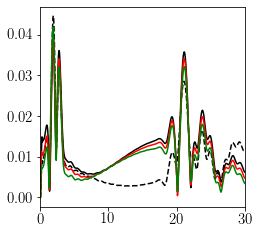

In [31]:
# convergence
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.92

ax0 = plt.subplot(1,1,1)

# Delta =1.3
files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"k",label="$\Delta n=0.02$")
# ax0.hlines(np.abs(imp.obs.rho_loc.data[0,0,1]),0,100,"k",label="Eq")

files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"k--",label="$\Delta n=0.02$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"k--",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"r",label="$\Delta n=0.02$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"r--",label="$\Delta n=0.02$")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.01_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.05/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]-imp.obs.rho_loc.data[0,0,1]),"g",label="$\Delta n=0.02$")

# files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.01_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk128_mazza0.05/output/out_full_local.out"
# imp = read_imp_h5file(files,["obs","parm"])
# dt=imp.parm.h[0]
# t=np.arange(imp.parm.nt[0]+2)*dt
# n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
# ax0.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1]),"g--",label="$\Delta n=0.02$")

ax0.set_xlim(0,30)
# ax0.set_yscale("log")


# ax0.set_ylim(0,1)


In [34]:
2*np.pi/20

0.3141592653589793

In [133]:
140*1.2/1.3

129.23076923076923

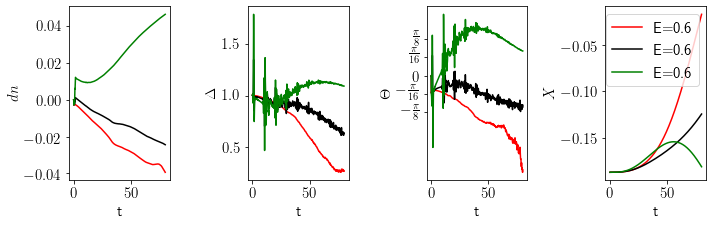

In [24]:
%matplotlib inline

mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.2
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.95

ax0 = plt.subplot(1,4,1)
ax1 = plt.subplot(1,4,2)
ax2 = plt.subplot(1,4,3)
ax3 = plt.subplot(1,4,4)


time=1.0 # 1.96

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"r-",label="E=0.4")
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"r-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"r-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"r-",label="E=0.6")

files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"k-",label="E=0.4")
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"k-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"k-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"k-",label="E=0.6")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.3_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"g-",label="E=0.4")
ax1.plot(t*time,np.abs(imp.obs.rho_loc.data[:,0,1])/np.abs(imp.obs.rho_loc.data[0,0,1]),"g-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"g-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"g-",label="E=0.6")


ax0.set_xlabel("t")
ax0.set_ylabel("$dn$")

ax1.set_xlabel("t")
ax1.set_ylabel("$\Delta$")

ax2.set_yticks([-np.pi/8.0, -np.pi/16.0, 0, np.pi/16.0, np.pi/8.0])
ax2.set_yticklabels([r'$-\frac{\pi}{8}$', r'$-\frac{\pi}{16}$', r'$0$', r'$\frac{\pi}{16}$', r'$\frac{\pi}{8}$'])
ax2.set_xlabel("t")
ax2.set_ylabel("$\Theta$")

ax3.set_xlabel("t")
ax3.set_ylabel("$X$")

#ax0.set_xlim(0,25)
#ax1.set_xlim(0,25)
#ax2.set_xlim(0,25)
#ax3.set_xlim(0,25)

plt.legend()

plt.tight_layout()

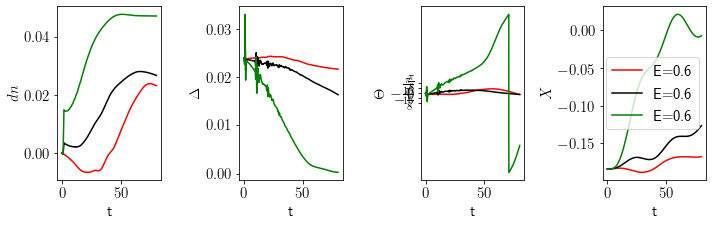

In [21]:
%matplotlib inline

mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.2
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.95

ax0 = plt.subplot(1,4,1)
ax1 = plt.subplot(1,4,2)
ax2 = plt.subplot(1,4,3)
ax3 = plt.subplot(1,4,4)


time=1.0 # 1.96

files="../abinitio/2b/calc_U1.8_E00.0_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"r-",label="E=0.4")
ax1.plot(t*time,0.26*(np.abs(imp.obs.rho_loc.data[:,0,1])),"r-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"r-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"r-",label="E=0.6")


files="../abinitio/2b/calc_U1.8_E00.2_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"k-",label="E=0.4")
ax1.plot(t*time,0.26*(np.abs(imp.obs.rho_loc.data[:,0,1])),"k-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"k-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"k-",label="E=0.6")


files="../abinitio/2b/calc_U1.8_E00.4_om6.0_om00.2_lam0.1_approx3_phonon1_delta-1.1_t00.0_migdal1_nt4000_mu0.3_beta20.0_ntau1500_dt0.02_err5e-07_bath0.0_gBATH0.2_omBATH1.0_nk64_mazza0.0/output/out_full_local.out"
imp = read_imp_h5file(files,["obs","parm"])
dt=imp.parm.h[0]
t=np.arange(imp.parm.nt[0]+2)*dt
n=imp.obs.rho_loc.data[:,0,0]-imp.obs.rho_loc.data[:,1,1]
ax0.plot(t*time,n-n[0],"g-",label="E=0.4")
ax1.plot(t*time,0.26*(np.abs(imp.obs.rho_loc.data[:,0,1])),"g-",label="E=0.4")
ax2.plot(t*time,shift(np.angle(imp.obs.rho_loc.data[:,0,1])),"g-",label="E=0.4")
ax3.plot(t*time,imp.obs.X.data[:,0,0],"g-",label="E=0.6")



ax0.set_xlabel("t")
ax0.set_ylabel("$dn$")

ax1.set_xlabel("t")
ax1.set_ylabel("$\Delta$")

ax2.set_yticks([-np.pi/8.0, -np.pi/16.0, 0, np.pi/16.0, np.pi/8.0])
ax2.set_yticklabels([r'$-\frac{\pi}{8}$', r'$-\frac{\pi}{16}$', r'$0$', r'$\frac{\pi}{16}$', r'$\frac{\pi}{8}$'])
ax2.set_xlabel("t")
ax2.set_ylabel("$\Theta$")

ax3.set_xlabel("t")
ax3.set_ylabel("$X$")

#ax0.set_xlim(0,25)
#ax1.set_xlim(0,25)
#ax2.set_xlim(0,25)
#ax3.set_xlim(0,25)

plt.legend()

plt.tight_layout()

# Fig 2

In [8]:
from SpectrumCNTRhdf5 import read_gf_ret_let_tavtrel,evaluate_spectrum_windowed,evaluate_spectrum_windowed_withwidth,evaluate_spectrum,evaluate_occupation,evaluate_occupation_windowed,evaluate_occupation_windowed_withwidth,read_gf_les_slice,read_gf_ret_slice,fourier_t2w

def get_self(file,tslice,twindow,dt,prop="Sigma"):
    assert (tslice >= twindow),"Slice shorter than window"
    
    ome = np.linspace(-10.0,10.0,3000)
    t_rel,S_ret = read_gf_ret_slice(file,prop,dt,int(tslice/dt))

    data=S_ret[0:int(twindow/dt)]
    t_rel=t_rel[0:int(twindow/dt)]
    St = -np.concatenate((-data[::-1], data.conj() ))
    t = np.concatenate((-t_rel[::-1], t_rel))
    w=np.blackman(len(t))

    St[:,0,0]=St[:,0,0]*w
    St[:,0,1]=St[:,0,1]*w
    St[:,1,0]=St[:,1,0]*w
    St[:,1,1]=St[:,1,1]*w

    S_w1=fourier_t2w(St[:,0,0],t,ome,'simpson')
    S_w2=fourier_t2w(St[:,0,1],t,ome,'simpson')
    S_w3=fourier_t2w(St[:,1,0],t,ome,'simpson')
    S_w4=fourier_t2w(St[:,1,1],t,ome,'simpson')
    
    return [ome,-S_w1.imag,-S_w2.imag,-S_w3.imag,-S_w4.imag]

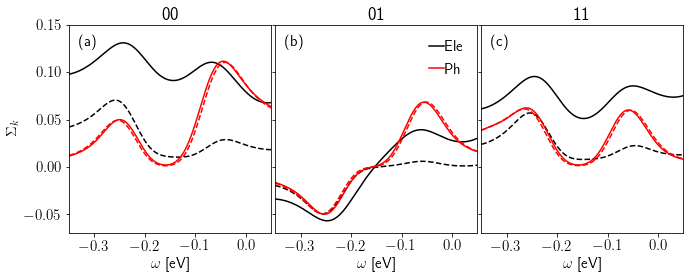

In [34]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


twindow=40.0

fig, ax = plt.subplots(1, 3)


imp=read_imp_h5file_slices("../nobackupres_2bLARGE/calc_U3.0_E00.0_om6.0_om00.1_lam0.1_approx3_phonon1_delta-2.4/output/out_k0.out",["parm"])
dt=imp.parm.h[0]


file="../abinitio/data/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k32.out"
[om,Aw1,Aw2,Aw3,Aw4]=get_self(file,80.0,twindow,dt,"Sigma")
ax[0].plot((om-0.264)*0.33,Aw1,"k--")
ax[1].plot((om-0.264)*0.33,Aw2,"k--")
ax[2].plot((om-0.264)*0.33,Aw4,"k--")

file="../abinitio/data/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k32.out"
[om,Aw1,Aw2,Aw3,Aw4]=get_self(file,80.0,twindow,dt,"Sigma")
ax[0].plot((om-0.264)*0.33,Aw1,"k-")
ax[1].plot((om-0.264)*0.33,Aw2,"k-",label="Ele")
ax[2].plot((om-0.264)*0.33,Aw4,"k-")



file="../abinitio/data/calc_U0.0_E00.0_om6.0_om00.05_lam1.0_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k32.out"
[om,Aw1,Aw2,Aw3,Aw4]=get_self(file,80.0,twindow,dt,"Sigma")
ax[0].plot((om-0.264)*0.33,Aw1,"r--")
ax[1].plot((om-0.264)*0.33,Aw2,"r--")
ax[2].plot((om-0.264)*0.33,Aw4,"r--")

file="../abinitio/data/calc_U0.0_E00.6_om6.0_om00.05_lam1.0_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k32.out"
[om,Aw1,Aw2,Aw3,Aw4]=get_self(file,80.0,twindow,dt,"Sigma")
ax[0].plot((om-0.264)*0.33,Aw1,"r-")
ax[1].plot((om-0.264)*0.33,Aw2,"r-",label="Ph")
ax[2].plot((om-0.264)*0.33,Aw4,"r-")


ax[0].set_xlim(-0.35,0.05)
ax[0].set_ylim(-0.07,0.15)

ax[1].set_xlim(-0.35,0.05)
ax[1].set_ylim(-0.07,0.15)

ax[2].set_xlim(-0.35,0.05)
ax[2].set_ylim(-0.07,0.15)




ax[0].set_xlabel("$\omega$~[eV]")
ax[0].set_ylabel("$\Sigma_k$")
ax[0].set_title("00")

ax[1].set_xlabel("$\omega$~[eV]")
ax[1].get_yaxis().set_ticklabels([])
ax[1].set_title("01")

ax[2].set_xlabel("$\omega$~[eV]")
ax[2].get_yaxis().set_ticklabels([])
ax[2].set_title("11")

ax[0].text(0.05,0.9,"(a)",transform=ax[0].transAxes)
ax[1].text(0.05,0.9,"(b)",transform=ax[1].transAxes)
ax[2].text(0.05,0.9,"(c)",transform=ax[2].transAxes)


plt.subplots_adjust(wspace = 0.02)

ax[1].legend(frameon=False,handlelength=1,handletextpad=0.1)
plt.savefig("fin/fig4.svg")

# Fig 3

In [112]:
# OLD data
####
# U=3
####
# EU3=np.array([0.0,0.2,0.4,0.6])
# nU3=np.array([0.0,0.0049,0.0212,0.05912])
# dmuU3k0=np.array([0.0,0.0349243,0.0661954,0.11451439554])
# dmuU3k1=np.array([0.0,0.040198,0.0886919,0.233623])
# dmuU3k2=np.array([0.0,0.0262819,0.05966796,0.10261854])

# sigmaU3k0Eq=0.053609
# sigmaU3k1Eq=0.0530808
# sigmaU3k2Eq=0.051916

# dsigmaU3k0=np.array([0,0.0122,0.0464514,0.084409])
# dsigmaU3k1=np.array([0,0.0104,0.0348629,0.072158])
# dsigmaU3k2=np.array([0,0.0056,0.03122082,0.0952526])

# # ####
# # # U=2
# # ####
# nU2=np.array([0.0,0.00917,0.0415713,0.10079])
# dmuU2k0=np.array([0.0,0.0112,0.053516996,0.06628898])
# dmuU2k1=np.array([0.0,0.0139224,0.0648043,0.112110])
# dmuU2k2=np.array([0.0,0.0058122,0.0190279,0.034294594])

# sigmaU2k0Eq=0.056582
# sigmaU2k1Eq=0.0564579141
# sigmaU2k2Eq=0.0562819

# dsigmaU2k0=np.array([0,0.01026,0.032896,0.06303])
# dsigmaU2k1=np.array([0,0.00800,0.023736,0.06237])
# dsigmaU2k2=np.array([0,0.0095,0.04036,0.0586019])


# # ####
# # # U=1
# # ####
# nU1=np.array([0,0.01492,0.053799395,0.112414])
# dmuU1k0=np.array([0,0.0070660,0.0238476922930,0.02795919])
# dmuU1k1=np.array([0,0.0112975,0.043532,0.0734640256])
# dmuU1k2=np.array([0,0.0023952,0.008559340,0.01398858])

# sigmaU1k0Eq=0.05823571
# sigmaU1k1Eq=0.05890860486877
# sigmaU1k2Eq=0.05867904226

# dsigmaU1k0=np.array([0,0.00291227,0.00906189,0.0157551])
# dsigmaU1k1=np.array([0,0.00227422,0.0078442,0.0270355])
# dsigmaU1k2=np.array([0,0.0022247,0.00733717,0.0137260])

# # ####
# # # U=0.3
# # ####

# nU03=np.array([0.0,0.00889,0.02767,0.05757])
# dmuU03k0=np.array([0.0,0.00085,0.003290,0.006144])
# dmuU03k1=np.array([0.0,0.002437646,0.00991,0.021444])
# dmuU03k2=np.array([0.0,0.000522,0.002319,0.004898])

# sigmaU03k0Eq=0.057311
# sigmaU03k1Eq=0.058704802783
# sigmaU03k2Eq=0.052543

# dsigmaU03k0=np.array([0,0.0002458,0.0003814,0.000515])
# dsigmaU03k1=np.array([0,0.000524,0.001415,0.003154])
# dsigmaU03k2=np.array([0,0.000124,0.0004879010,0.001005])

In [3]:
# ####
# # U=2.5, lam=0.0
# ####
# E_l0=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l0=np.array([0.0,0.0043,0.0161,0.0369417782,0.0668094])

# mu_l0_k0=np.array([-0.18321605,-0.17789565,-0.15675848,-0.13520177,-0.13870872])
# mu_l0_k1=np.array([-0.16896962,-0.16220072,-0.13642601,-0.10731686,-0.09978186])
# mu_l0_k2=np.array([-0.18470918,-0.17795091,-0.15289679,-0.12269919,-0.10316006])


# sigma_l0_k0=np.array([0.0186661,0.02393624,0.04018387,0.05598228,0.07137118])
# sigma_l0_k1=np.array([0.01849381,0.02324077,0.0371246,0.049209180,0.06144676])
# sigma_l0_k2=np.array([0.01793277,0.02117567,0.03023419,0.0377457,0.04449891])

# ####
# # U=2.3, lam=0.1
# ####
# E_l01=np.array([0.0,0.2,0.4,0.6,0.8])

# n_l01=np.array([0.0,0.004,0.0141,0.0320,0.0577969])
# mu_l01_k0=np.array([-0.18428414, -0.17912135, -0.15995337, -0.13440317,-0.12833833])
# mu_l01_k1=np.array([-0.17064934, -0.16402898, -0.14029197,-0.10806702,-0.0926714])
# mu_l01_k2=np.array([-0.18834344, -0.18151675, -0.15825757,-0.12776405,-0.10576256])


# sigma_l01_k0=np.array([0.0197137,  0.02411309, 0.03707239,0.05073224,0.06426554])
# sigma_l01_k1=np.array([0.01929672, 0.0232616,  0.03456431,0.04492219,0.05398895])
# sigma_l01_k2=np.array([0.01890778, 0.02164553, 0.0290239,0.03530401, 0.04080806])

# ####
# # U=1.5, lam=0.5
# ####
# E_l05=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l05=np.array([0.0,0.002,0.00916,0.020186,0.035628])

# mu_l05_k0=np.array([-0.18664662,-0.1832368 ,-0.17263232,-0.15460174,-0.13294555])
# mu_l05_k1=np.array([-0.1748952,-0.17108613,-0.15910409,-0.13844027,-0.11166948])
# mu_l05_k2=np.array([-0.199169,-0.19535978,-0.18360508,-0.16451017,-0.14071308])


# sigma_l05_k0=np.array([0.02513754,0.02633184,0.02969772,0.03442426,0.03932164])
# sigma_l05_k1=np.array([0.02380906,0.02491056,0.02806857,0.03251077,0.0364007])
# sigma_l05_k2=np.array([0.02358311,0.02440227,0.02661931,0.02941224,0.03147886])

# ####
# # U=0.5, lam=1.0
# ####
# E_l1=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l1=np.array([0.0,0.002,0.0068,0.014234453673,0.024356])


# mu_l1_k0=np.array([-0.18655526,-0.18520289,-0.18122378,-0.17476764,-0.16604771])
# mu_l1_k1=np.array([-0.17596922,-0.17458348,-0.1705258,-0.16392278,-0.15495116])
# mu_l1_k2=np.array([-0.20544572,-0.20428956,-0.2008642,-0.19530179,-0.18782418])


# sigma_l1_k0=np.array([0.03358392,0.03357751,0.03355794,0.03352887,0.03350026])
# sigma_l1_k1=np.array([0.0314665,0.03146254,0.03145799,0.03145718,0.03146492])
# sigma_l1_k2=np.array([0.03018225,0.03018934,0.0302053,0.03021797,0.03020657])

In [119]:
# # Effect of bath
# ####
# # U=2.5, lam=0.0
# ####
# Ebath=np.array([0.0,0.1,0.2])
# nB_l0=np.array([0.0,0.04269,0.12837])

# muB_l0_k0=np.array([-0.18321605,-0.0710557,-0.09690833])
# muB_l0_k1=np.array([-0.16896962,-0.04409881,-0.07042316])
# muB_l0_k2=np.array([-0.18470918,-0.07171128,-0.08608101])


# sigmaB_l0_k0=np.array([0.0186661,0.05556098,0.07881068])
# sigmaB_l0_k1=np.array([0.01849381,0.05027706,0.06997206])
# sigmaB_l0_k2=np.array([0.01793277,0.03974368,0.05088163])

# ####
# # U=2.3, lam=0.1
# ####
# nB_l01=np.array([0,0.042,0.128])

# muB_l01_k0=np.array([-0.18428414,-0.06669948,-0.08331888])
# muB_l01_k1=np.array([-0.17064934,-0.0449601,-0.06050827])
# muB_l01_k2=np.array([-0.18834344,-0.07804717,-0.08721926])


# sigmaB_l01_k0=np.array([0.0197137,0.0494080,0.07316803])
# sigmaB_l01_k1=np.array([0.01929672,0.04240008,0.06060724])
# sigmaB_l01_k2=np.array([0.01890778,0.03692929,0.04481544])

# ####
# # U=1.5, lam=0.5
# ####

# nB_l05=np.array([0,0.0383,0.11348059])

# muB_l05_k0=np.array([-0.18664662,-0.0652399,-0.02450409])
# muB_l05_k1=np.array([-0.1748952,-0.05741948,-0.0475289])
# muB_l05_k2=np.array([-0.199169,-0.10992777,-0.10686044])


# sigmaB_l05_k0=np.array([0.02513754,0.03549316,0.06275292])
# sigmaB_l05_k1=np.array([0.02380906,0.03044183,0.03362353])
# sigmaB_l05_k2=np.array([0.02358311,0.0280201,0.02856818])

# ####
# # U=0.5, lam=1.0
# ####

# nB_l1=np.array([0,0.033541,0.085705])

# muB_l1_k0=np.array([-0.1865552,-0.08399404,-0.01493214])
# muB_l1_k1=np.array([-0.17596921,-0.08247237,-0.05653533])
# muB_l1_k2=np.array([-0.20544569,-0.14166899,-0.1287399])


# sigmaB_l1_k0=np.array([0.03358375,0.03071089,0.03214087])
# sigmaB_l1_k1=np.array([0.0314665,0.02847489,0.02494659])
# sigmaB_l1_k2=np.array([0.03018207,0.02483587,0.01980734])

In [17]:
# Small gap - twindow=60
####
# U=2.0, lam=0.0
####
E_l0=np.array([0.0,0.2,0.4,0.6,0.8])
n_l0=np.array([0.0,0.00373,0.014072,0.0322149,0.0578967])

mu_l0_k0=np.array([-0.12393013,-0.11907248,-0.10582721,-0.09729481,-0.10198674])
mu_l0_k1=np.array([-0.12047678,-0.11384991,-0.09530929,-0.07918781,-0.07461002])
mu_l0_k2=np.array([-0.16589483,-0.15933978,-0.14155034,-0.12339376,-0.10964582])

sigma_l0_k0=np.array([0.02467359, 0.02973908, 0.04431146, 0.06271489, 0.08025267])
sigma_l0_k1=np.array([0.02450784, 0.02868579, 0.0393924,  0.05015207, 0.06128464])
sigma_l0_k2=np.array([0.02429455, 0.0270271,  0.03414217, 0.04130791, 0.04771311])


fwhm_l0_k0=np.array([0.03974612, 0.04665848, 0.06566749, 0.08986078, 0.11578216])
fwhm_l0_k1=np.array([0.03974612, 0.04493039, 0.05875513, 0.07257986, 0.08813269])
fwhm_l0_k2=np.array([0.03974612, 0.0432023,  0.05011467, 0.06048322, 0.06912368])

####
# U=1.8, lam=0.1
####
E_l01=np.array([0.0,0.2,0.4,0.6,0.8])
n_l01=np.array([0.0,0.003580,0.01262,0.0282,0.050481])

mu_l01_k0=np.array([-0.1242409,-0.12001138, -0.10800535, -0.09529857, -0.0927229 ])
mu_l01_k1=np.array([-0.12204078, -0.11662665, -0.10067207, -0.08169045, -0.07118747])
mu_l01_k2=np.array([-0.16941597, -0.16422827, -0.14920059, -0.13031414, -0.11493186])


sigma_l01_k0=np.array([0.02596329, 0.02965214, 0.04000965, 0.05440536, 0.07007497])
sigma_l01_k1=np.array([0.02567702, 0.02875636, 0.03673848, 0.04491075, 0.05279113])
sigma_l01_k2=np.array([0.02488033, 0.02697064, 0.03243244, 0.03807956, 0.04297001])


fwhm_l01_k0=np.array([0.0432023,0.04493039,0.05875513,0.07949223,0.10022933])
fwhm_l01_k1=np.array([0.04147421,0.04493039,0.05529894,0.06566749,0.07603605])
fwhm_l01_k2=np.array([0.03974612,0.0432023,0.04838658,0.05529894,0.06221131])

####
# U=1.0, lam=0.5
####

E_l05=np.array([0.0,0.2,0.4,0.6,0.8])
n_l05=np.array([0.0,0.002,0.008,0.017,0.03])

mu_l05_k0=np.array([-0.12474806, -0.12302211, -0.11799008, -0.1101665,  -0.10038404])
mu_l05_k1=np.array([-0.12530014, -0.12335946, -0.11762974, -0.10839367, -0.09633479])
mu_l05_k2=np.array([-0.17804179, -0.17634241, -0.1713008,  -0.16320064, -0.15264994])


sigma_l05_k0=np.array([0.03212799, 0.03263325, 0.03405037, 0.03616505, 0.03901066])
sigma_l05_k1=np.array([0.03130446, 0.03174872, 0.03299711, 0.03479723, 0.03675175])
sigma_l05_k2=np.array([0.02712799, 0.02748821, 0.02849325, 0.02991987, 0.03146004])

fwhm_l05_k0=np.array([0.05011467, 0.05184276, 0.05357085, 0.05702704, 0.06048322])
fwhm_l05_k1=np.array([0.04838658, 0.05011467, 0.05184276, 0.05357085, 0.05702704])
fwhm_l05_k2=np.array([0.0432023,  0.0432023,  0.04493039, 0.04665848, 0.04838658])

####
# U=0.0, lam=1.0
####

E_l1=np.array([0.0,0.2,0.4,0.6,0.8,1.0,1.2,1.4])
n_l1=np.array([0.0,0.002,0.0068,0.013,0.022,0.0337,0.047259,0.0624076])

mu_l1_k0=np.array([-0.12152086, -0.12081009, -0.11866545, -0.11514495, -0.11033798, -0.10435748, -0.09733324, -0.0894078 ])
mu_l1_k1=np.array([-0.12373095, -0.12310344, -0.12122595, -0.11816512, -0.11402637, -0.10894825, -0.10309687, -0.09666257])
mu_l1_k2=np.array([-0.18043697, -0.18007203, -0.17894056, -0.17709759, -0.17462694, -0.17163414, -0.16824038, -0.1645738 ])


sigma_l1_k0=np.array([0.04250741, 0.04250697, 0.04250783, 0.04251848, 0.04254499, 0.04257862, 0.04258351, 0.04249283])
sigma_l1_k1=np.array([0.04010469, 0.04010751, 0.04011439, 0.0401321,  0.04016383, 0.04019851, 0.04019963, 0.04010238])
sigma_l1_k2=np.array([0.03099312, 0.030949,   0.030822,   0.03061546, 0.03033236, 0.02997283, 0.02953687, 0.02903645])

fwhm_l1_k0=np.array([0.06912368, 0.06912368, 0.06912368, 0.06912368, 0.06739559, 0.06912368, 0.06912368, 0.06739559])
fwhm_l1_k1=np.array([0.06566749, 0.0639394,  0.0639394,  0.06566749, 0.0639394,  0.0639394, 0.0639394,  0.0639394 ])
fwhm_l1_k2=np.array([0.04665848, 0.04838658, 0.04665848, 0.04665848, 0.04665848, 0.04665848, 0.04493039, 0.04493039])

In [5]:
# # Small gap - twindow=30
# ####
# # U=2.0, lam=0.0
# ####

# E_l0=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l0=np.array([0.0,0.0037, 0.0140,0.0322,0.0584])

# mu_l0_k0=np.array([-0.12498026, -0.12190606, -0.11332628, -0.10394147, -0.10247761])
# mu_l0_k1=np.array([-0.12182801, -0.11709912, -0.10333474, -0.0862741,  -0.0762755 ])
# mu_l0_k2=np.array([-0.16698173, -0.16161323, -0.14648701, -0.12748683, -0.11217466])

# sigma_l0_k0=np.array([0.04705415, 0.04993759, 0.05886904, 0.07488698, 0.09347265])
# sigma_l0_k1=np.array([0.0470071 , 0.04958266, 0.05663938, 0.06584323, 0.07700987])
# sigma_l0_k2=np.array([0.04700494, 0.04877557, 0.05357049, 0.05933216, 0.06466575])

# ####
# # U=1.8, lam=0.1
# ####
# E_l01=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l01=np.array([0.0,0.003580,0.01262,0.0282,0.050481])

# mu_l01_k0=np.array([-0.12560481, -0.12323951, -0.11658135, -0.10792428, -0.10240665])
# mu_l01_k1=np.array([-0.12309823, -0.11954839, -0.10908448, -0.09428269, -0.08185342])
# mu_l01_k2=np.array([-0.16953624, -0.16565679, -0.15432311, -0.13812443, -0.12241893])


# sigma_l01_k0=np.array([0.04798333, 0.05000669, 0.05598964, 0.06637557, 0.080541])
# sigma_l01_k1=np.array([0.04784905, 0.04965252, 0.05466143, 0.06145013, 0.06905504])
# sigma_l01_k2=np.array([0.04756177, 0.0488385 , 0.05233748, 0.05685236, 0.06111322])

# ####
# # U=1.0, lam=0.5
# ####

# E_l05=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l05=np.array([0.0,0.002,0.008,0.017,0.03])

# mu_l05_k0=np.array([-0.12664736, -0.12594736, -0.12392473, -0.12078808, -0.11684891])
# mu_l05_k1=np.array([-0.12693871, -0.12595497, -0.1230838,  -0.11847736, -0.11239278])
# mu_l05_k2=np.array([-0.17721018, -0.17615957, -0.17305268, -0.16805661, -0.16143709])


# sigma_l05_k0=np.array([0.05227947, 0.05255108, 0.05333712, 0.05457924, 0.05623276])
# sigma_l05_k1=np.array([0.05167419, 0.05192503, 0.05265835, 0.05381124, 0.05527112])
# sigma_l05_k2=np.array([0.04990587, 0.05011057, 0.05070186, 0.0516117,  0.05274054])

# ####
# # U=0.0, lam=1.0
# ####
# E_l1=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l1=np.array([0.0,0.002,0.0068,0.013,0.022])

# mu_l1_k0=np.array([-0.12333905, -0.12300263, -0.12198397, -0.12030596, -0.1180048 ])
# mu_l1_k1=np.array([-0.12537757, -0.12507596, -0.12417693, -0.12270488, -0.120698  ])
# mu_l1_k2=np.array([-0.17893342, -0.17876228, -0.1782066 , -0.17728445, -0.17602451])


# sigma_l1_k0=np.array([0.05963133, 0.05962622, 0.05960122, 0.05955617, 0.05949062])
# sigma_l1_k1=np.array([0.05778864, 0.05778002, 0.05774838, 0.05769484, 0.05762106])
# sigma_l1_k2=np.array([0.0531973,  0.05318368, 0.05314242, 0.05307404, 0.05297947])

In [ ]:
# # Small gap - deeper in BEC delta=-1.1
# ####
# # U=2.0, lam=0.0
# ####

# E_l0=np.array([0.0,0.2,0.4,0.6])
# n_l0=np.array([0.0,0.006632667669139922, 0.014705259687288003,0.028332824174636312])

# mu_l0_k0=np.array([-0.11999197, -0.11506485, -0.10103764, -0.08947786])
# mu_l0_k1=np.array([-0.12330704, -0.11695276, -0.09849197, -0.07985737])
# mu_l0_k2=np.array([-0.17742436, -0.17100974, -0.15297947, -0.13295549])

# sigma_l0_k0=np.array([0.02426427, 0.02869733, 0.04179467, 0.06044188])
# sigma_l0_k1=np.array([0.02412324, 0.02784442, 0.03784919, 0.0481266 ])
# sigma_l0_k2=np.array([0.02402461, 0.02664184, 0.03374823, 0.04103234])


# ####
# # U=1.0, lam=0.5
# ####

# E_l05=np.array([0.0,0.2,0.4,0.6,0.8])
# n_l05=np.array([0.0,0.00586,0.0112,0.0199])



# mu_l05_k0=np.array([-0.12014263, -0.11855688, -0.11387855, -0.1064272 ])
# mu_l05_k1=np.array([-0.12730459, -0.12558557, -0.12047025, -0.11214957])
# mu_l05_k2=np.array([-0.18776985, -0.18626623, -0.18176857, -0.17447514])


# sigma_l05_k0=np.array([0.03096411, 0.03141671, 0.03270144, 0.03464226])
# sigma_l05_k1=np.array([0.03035346, 0.03075254, 0.03188642, 0.03354982])
# sigma_l05_k2=np.array([0.02595693, 0.02628055, 0.02719527, 0.02853658])


# Fig3 alternative

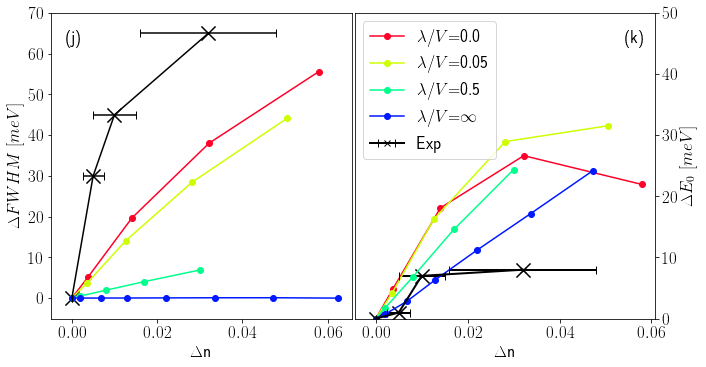

In [24]:
%matplotlib inline
mpl.rcParams['font.size'] = 17
mpl.rcParams['legend.fontsize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*2,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95



fig, ax = plt.subplots(1,2,figsize=(10,5))


lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow

bath=False


ax[0].plot(n_l0,(sigma_l0_k0-sigma_l0_k0[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda/V$=0.0")
ax[0].plot(n_l01,(sigma_l01_k0-sigma_l01_k0[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda/V$=0.05")
ax[0].plot(n_l05,(sigma_l05_k0-sigma_l05_k0[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda/V$=0.5")
ax[0].plot(n_l1,(sigma_l1_k0-sigma_l1_k0[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda/V$=$\infty$")



ax[0].set_xlabel("$\Delta$n")
ax[0].set_ylabel("$\Delta FWHM~[meV]$")

fluence=np.array([0,0.005,0.01,0.032])
shift0=np.array([0,30,45,65])
shift1=np.array([0,30,43,63])
shift2=np.array([0,20,32,53])

ax[0].errorbar(fluence,shift0,xerr=fluence*0.5,capsize=4,color="k",label="Exp")
ax[0].scatter(fluence,shift0,s = 200, marker = "x", color = "k")

ax[1].plot(n_l0,(mu_l0_k0-mu_l0_k0[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda/V$=0.0")
ax[1].plot(n_l01,(mu_l01_k0-mu_l01_k0[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda/V$=0.05")
ax[1].plot(n_l05,(mu_l05_k0-mu_l05_k0[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda/V$=0.5")
ax[1].plot(n_l1[:-1],(mu_l1_k0[:-1]-mu_l1_k0[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda/V$=$\infty$")


fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
# ax0.errorbar(fluence,shift,"k-",lw=2,xerr=0.01,label="Exp")
ax[1].errorbar(fluence,shift,xerr=fluence*0.5,color="k",marker="x",capsize=4,lw=2,label="Exp")
ax[1].scatter(fluence, shift, s = 200, marker = "x", color = "k")

ax[1].set_ylabel("$d\mu~[meV]$")
ax[1].set_xlabel("$\Delta$n")
ax[1].set_ylabel("$\Delta E_0~[meV]$")

ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()


plt.subplots_adjust(wspace=0.01)

ax[1].set_ylim(0,50)

ax[1].legend()

ax[0].text(0.05,0.9,"(j)",transform=ax[0].transAxes)
ax[1].text(0.9,0.9,"(k)",transform=ax[1].transAxes)

plt.savefig("fin/fig3new.svg")

# Self-energy

In [30]:
from SpectrumCNTRhdf5 import read_gf_ret_let_tavtrel,evaluate_spectrum_windowed,evaluate_spectrum_windowed_withwidth,evaluate_spectrum,evaluate_occupation,evaluate_occupation_windowed,evaluate_occupation_windowed_withwidth,read_gf_les_slice,read_gf_ret_slice,fourier_t2w

def fit_self(file,tslice,twindow,dt,color,lw=1):
    assert (tslice >= twindow),"Slice shorter than window"
    
    ome = np.linspace(-10.0,10.0,3000)
    t_rel,S_ret = read_gf_ret_slice(file,"Sigma",dt,int(tslice/dt))

    data=S_ret[0:int(twindow/dt)]
    t_rel=t_rel[0:int(twindow/dt)]
    St = -np.concatenate((-data[::-1], data.conj() ))
    t = np.concatenate((-t_rel[::-1], t_rel))
    w=np.blackman(len(t))

    St[:,0,0]=St[:,0,0]*w
    St[:,0,1]=St[:,0,1]*w
    St[:,1,0]=St[:,1,0]*w
    St[:,1,1]=St[:,1,1]*w

    S_w1=fourier_t2w(St[:,0,0],t,ome,'simpson')
    S_w2=fourier_t2w(St[:,0,1],t,ome,'simpson')
    S_w3=fourier_t2w(St[:,1,0],t,ome,'simpson')
    S_w4=fourier_t2w(St[:,1,1],t,ome,'simpson')
    
    return [ome,-S_w1.imag,-S_w2.imag,-S_w3.imag,-S_w4.imag]

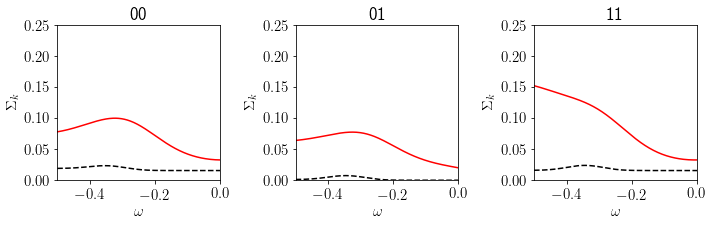

In [35]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3/2.54,8.6/2.54
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


times=np.array([80.0])

kpoints=np.array([32])
twindow=20.0

coef=np.zeros((3,len(times),3))
coef1=np.zeros((3,len(times),3))
coefEq=np.zeros((3,3))

fig, ax = plt.subplots(1, 3)



"../abinitio/data/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[1,indxk].plot((ome-0.264)*0.33,Nw,"k--",lw=2)
    file="../abinitio/data/calc_U1.8_E00.4_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,10.0,twindow)
    ax[1,indxk].plot((ome-0.264)*0.33,Nw,"r-",lw=2)

# Lattice    
for [indxk,k] in enumerate(kpoints):
#     print(k)
    file="../abinitio/data/calc_U0.0_E00.0_om6.0_om00.05_lam1.0_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,0.0,twindow)
    ax[2,indxk].plot((ome-0.264)*0.33,Nw,"k--",lw=2,label="Eq")
    file="../abinitio/data/calc_U0.0_E00.6_om6.0_om00.05_lam1.0_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k{}.out".format(k)
    [ome,Nw]=get_kslice(file,10.0,twindow)
    ax[2,indxk].plot((ome-0.264)*0.33,Nw,"r-",lw=2,label="t=140 fs")



imp=read_imp_h5file_slices("../nobackupres_2bLARGE/calc_U3.0_E00.0_om6.0_om00.1_lam0.1_approx3_phonon1_delta-2.4/output/out_k0.out",["parm"])
dt=imp.parm.h[0]


file="../abinitio/data/calc_U1.8_E00.0_om6.0_om00.05_lam0.1_approx3_phonon1_delta-1.0_t00.0_migdal1_nt5000_mu0.0_beta20.0_ntau1500_dt0.015_err5e-07_bath0.0/output/out_k32.out" 
[om,Aw1,Aw2,Aw3,Aw4]=fit_self(file,80.0,twindow,dt,"k",2)
ax[0].plot(om*hop,Aw1,"k--")
ax[1].plot(om*hop,Aw2,"k--")
ax[2].plot(om*hop,Aw4,"k--")

file="../nobackupres_2bLARGE/calc_U3.0_E00.4_om6.0_om00.1_lam0.1_approx3_phonon1_delta-2.4_t00.0/output/out_k{}.out".format(k)    
[om,Aw1,Aw2,Aw3,Aw4]=fit_self(file,80.0,twindow,dt,"k",2)
ax[0].plot(om*hop,Aw1,"k-")
ax[1].plot(om*hop,Aw2,"k-")
ax[2].plot(om*hop,Aw4,"k-")


file="../nobackupres_2bLARGE/calc_U3.0_E00.0_om6.0_om00.1_lam0.1_approx3_phonon1_delta-2.4/output/out_k32.out" 
[om,Aw1,Aw2,Aw3,Aw4]=fit_self(file,80.0,twindow,dt,"k",2)
ax[0].plot(om*hop,Aw1,"r--")
ax[1].plot(om*hop,Aw2,"r--")
ax[2].plot(om*hop,Aw4,"r--")

file="../nobackupres_2bLARGE/calc_U3.0_E00.4_om6.0_om00.1_lam0.1_approx3_phonon1_delta-2.4_t00.0/output/out_k{}.out".format(k)    
[om,Aw1,Aw2,Aw3,Aw4]=fit_self(file,80.0,twindow,dt,"k",2)
ax[0].plot(om*hop,Aw1,"r-")
ax[1].plot(om*hop,Aw2,"r-")
ax[2].plot(om*hop,Aw4,"r-")


ax[0].set_xlim(-0.5,0.0)
ax[0].set_ylim(0,0.25)

ax[1].set_xlim(-0.5,0.0)
ax[1].set_ylim(0,0.25)

ax[2].set_xlim(-0.5,0.0)
ax[2].set_ylim(0,0.25)



ax[0].set_xlabel("$\omega$")
ax[0].set_ylabel("$\Sigma_k$")
ax[0].set_title("00")

ax[1].set_xlabel("$\omega$")
ax[1].set_ylabel("$\Sigma_k$")
ax[1].set_title("01")

ax[2].set_xlabel("$\omega$")
ax[2].set_ylabel("$\Sigma_k$")
ax[2].set_title("11")

plt.tight_layout()

0
[0.     0.0025 0.005  0.016 ]


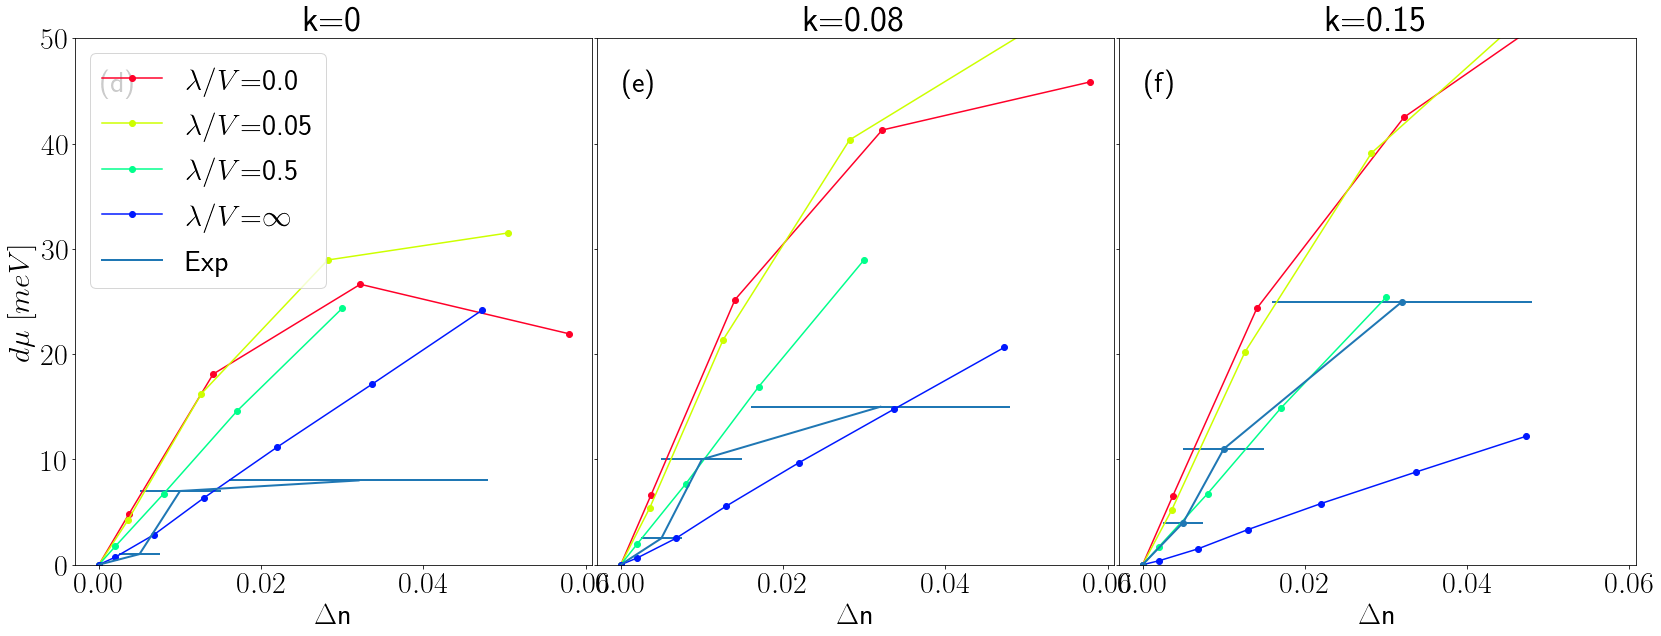

In [7]:
%matplotlib inline
mpl.rcParams['font.size'] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95


ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow
print(int(1/len(lam)))

bath=False

ax0.plot(n_l0,(mu_l0_k0-mu_l0_k0[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda/V$=0.0")
ax0.plot(n_l01,(mu_l01_k0-mu_l01_k0[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda/V$=0.05")
ax0.plot(n_l05,(mu_l05_k0-mu_l05_k0[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda/V$=0.5")
ax0.plot(n_l1[:-1],(mu_l1_k0[:-1]-mu_l1_k0[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda/V$=$\infty$")

if bath:
    ax0.plot(nB_l0,(muB_l0_k0-muB_l0_k0[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax0.plot(nB_l01,(muB_l01_k0-muB_l01_k0[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax0.plot(nB_l05,(muB_l05_k0-muB_l05_k0[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax0.plot(nB_l1[:-1],(muB_l1_k0[:-1]-muB_l1_k0[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")



fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
print(fluence*0.5)
# ax0.errorbar(fluence,shift,"k-",lw=2,xerr=0.01,label="Exp")
ax0.errorbar(fluence,shift,xerr=fluence*0.5,lw=2,label="Exp")


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\mu~[meV]$")
ax0.set_title("k=0")
ax0.set_ylim(0,50)

ax1.plot(n_l0,(mu_l0_k1-mu_l0_k1[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda$=0.0")
ax1.plot(n_l01,(mu_l01_k1-mu_l01_k1[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
ax1.plot(n_l05,(mu_l05_k1-mu_l05_k1[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
ax1.plot(n_l1[:-1],(mu_l1_k1[:-1]-mu_l1_k1[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

if bath:
    ax1.plot(nB_l0,(muB_l0_k1-muB_l0_k1[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax1.plot(nB_l01,(muB_l01_k1-muB_l01_k1[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax1.plot(nB_l05,(muB_l05_k1-muB_l05_k1[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax1.plot(nB_l1[:-1],(muB_l1_k1[:-1]-muB_l1_k1[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")


fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,2.5,10,15])
ax1.errorbar(fluence,shift,xerr=fluence*0.5,lw=2,label="Exp")
# ax1.plot(fluence,shift,"k-",lw=2)
ax1.set_title("k=0.08")
ax1.set_ylim(0,50)

ax2.plot(n_l0,(mu_l0_k2-mu_l0_k2[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda$=0.0")
ax2.plot(n_l01,(mu_l01_k2-mu_l01_k2[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
ax2.plot(n_l05,(mu_l05_k2-mu_l05_k2[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
ax2.plot(n_l1[:-1],(mu_l1_k2[:-1]-mu_l1_k2[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

if bath:
    ax2.plot(nB_l0,(muB_l0_k2-muB_l0_k2[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax2.plot(nB_l01,(muB_l01_k2-muB_l01_k2[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax2.plot(nB_l05,(muB_l05_k2-muB_l05_k2[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax2.plot(nB_l1[:-1],(muB_l1_k2[:-1]-muB_l1_k2[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")


fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,4,11,25])
ax2.errorbar(fluence,shift,xerr=fluence*0.5,lw=2,label="Exp",marker="o")
# ax2.errorbar(fluence/1000.0,shift,"k-",lw=2)
ax2.set_title("k=0.15")
ax2.set_ylim(0,50)


ax0.set_xlabel("$\Delta$n")
ax1.set_xlabel("$\Delta$n")
ax2.set_xlabel("$\Delta$n")

ax0.set_ylabel("$d\mu~[meV]$")
ax1.set_ylabel("")
ax2.set_ylabel("")

ax1.set_yticklabels([])
ax2.set_yticklabels([])

plt.subplots_adjust(wspace=0.01)

ax0.text(0.05,0.9,"(d)",transform=ax0.transAxes)
ax1.text(0.05,0.9,"(e)",transform=ax1.transAxes)
ax2.text(0.05,0.9,"(f)",transform=ax2.transAxes)


ax0.legend()

plt.savefig("fin/fig4a.svg")

In [39]:
pwd

'/mnt/ceph/users/dgolez/Projects/results/exciton/semiconductor_phonons/2b/vancouver/figures'

0


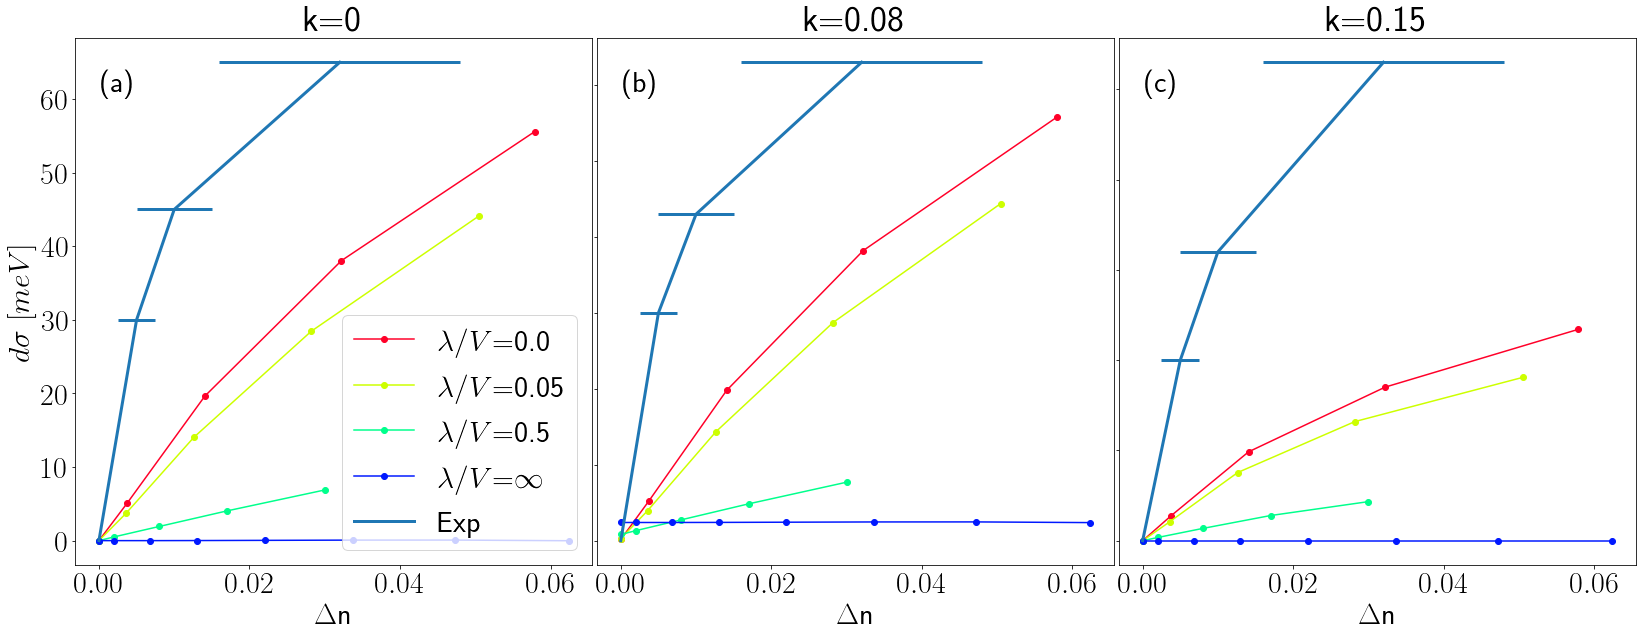

In [37]:
%matplotlib inline
mpl.rcParams['font.size'] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow
print(int(1/len(lam)))

bath=False

ax0.plot(n_l0,(sigma_l0_k0-sigma_l0_k0[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda/V$=0.0")
ax0.plot(n_l01,(sigma_l01_k0-sigma_l01_k0[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda/V$=0.05")
ax0.plot(n_l05,(sigma_l05_k0-sigma_l05_k0[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda/V$=0.5")
ax0.plot(n_l1,(sigma_l1_k0-sigma_l1_k0[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda/V$=$\infty$")

if bath:
    ax0.plot(nB_l0,sigmaB_l0_k0*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax0.plot(nB_l01,sigmaB_l01_k0*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax0.plot(nB_l05,sigmaB_l05_k0*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax0.plot(nB_l1,sigmaB_l1_k0*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\sigma~[meV]$")
ax0.set_title("k=0")


ax1.plot(n_l0,(sigma_l0_k0-sigma_l0_k1[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
ax1.plot(n_l01,(sigma_l01_k0-sigma_l01_k1[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax1.plot(n_l05,(sigma_l05_k0-sigma_l05_k1[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
ax1.plot(n_l1,(sigma_l1_k0-sigma_l1_k1[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax1.plot(nB_l0,sigmaB_l0_k1*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax1.plot(nB_l01,sigmaB_l01_k1*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax1.plot(nB_l05,sigmaB_l05_k1*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax1.plot(nB_l1,sigmaB_l1_k1*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


# ax1.plot(n_l0,(sigma_l0_k0-sigma_l0_k0[0])*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax1.plot(n_l01,(sigma_l01_k0-sigma_l01_k0[0])*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
# ax1.plot(n_l05,(sigma_l05_k0-sigma_l05_k0[0])*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax1.plot(n_l1,(sigma_l1_k0-sigma_l1_k0[0])*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax1.set_xlabel("dn")
ax1.set_ylabel("$d\sigma~[meV]$")
ax1.set_title("k=0.08")


ax2.plot(n_l0,(sigma_l0_k2-sigma_l0_k2[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
ax2.plot(n_l01,(sigma_l01_k2-sigma_l01_k2[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax2.plot(n_l05,(sigma_l05_k2-sigma_l05_k2[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax2.plot(n_l1,(sigma_l1_k2-sigma_l1_k2[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")
ax2.plot(n_l1,np.zeros(len(n_l1)),marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax2.plot(nB_l0,sigmaB_l0_k2*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax2.plot(nB_l01,sigmaB_l01_k2*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax2.plot(nB_l05,sigmaB_l05_k2*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax2.plot(nB_l1,sigmaB_l1_k2*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")
ax2.set_title("k=0.15")


fluence=np.array([0,0.005,0.01,0.032])
shift0=np.array([0,30,45,65])
shift1=np.array([0,30,43,63])
shift2=np.array([0,20,32,53])

ax0.errorbar(fluence,shift0,xerr=fluence*0.5,lw=3,label="Exp")
ax1.errorbar(fluence,shift1,xerr=fluence*0.5,lw=3)
ax2.errorbar(fluence,shift2,xerr=fluence*0.5,lw=3)


ax0.set_xlabel("$\Delta$n")
ax1.set_xlabel("$\Delta$n")
ax2.set_xlabel("$\Delta$n")

ax0.set_ylabel("$d\sigma~[meV]$")
ax1.set_ylabel("")
ax2.set_ylabel("")

ax1.set_yticklabels([])
ax2.set_yticklabels([])

ax0.text(0.05,0.9,"(a)",transform=ax0.transAxes)
ax1.text(0.05,0.9,"(b)",transform=ax1.transAxes)
ax2.text(0.05,0.9,"(c)",transform=ax2.transAxes)

plt.subplots_adjust(wspace=0.01)

ax0.legend(loc=4)
# plt.legend()
plt.savefig("fin/fig4b.svg")

0


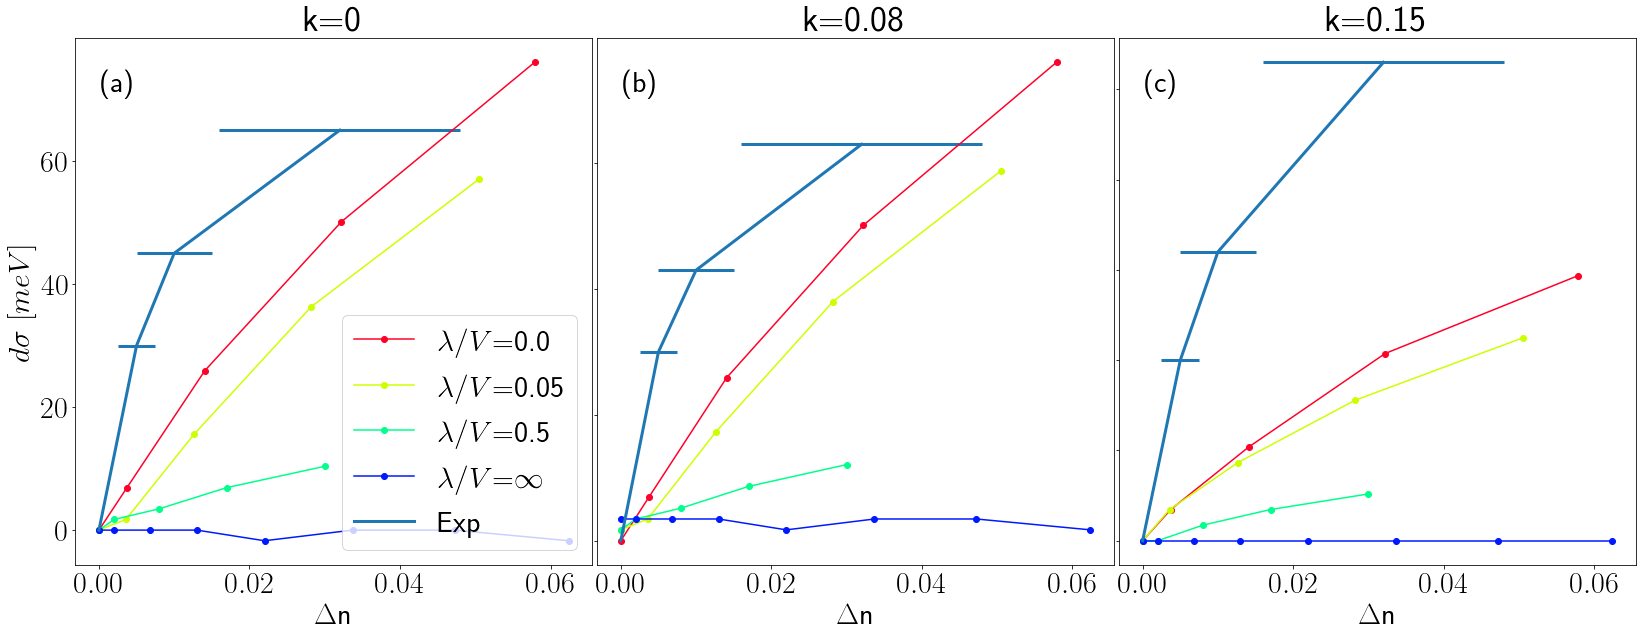

In [32]:
%matplotlib inline
mpl.rcParams['font.size'] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.1
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.1
mpl.rcParams["figure.subplot.top"] = 0.95

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow
print(int(1/len(lam)))

bath=False

ax0.plot(n_l0,(fwhm_l0_k0-fwhm_l0_k0[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda/V$=0.0")
ax0.plot(n_l01,(fwhm_l01_k0-fwhm_l01_k0[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda/V$=0.05")
ax0.plot(n_l05,(fwhm_l05_k0-fwhm_l05_k0[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda/V$=0.5")
ax0.plot(n_l1,(fwhm_l1_k0-fwhm_l1_k0[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda/V$=$\infty$")

if bath:
    ax0.plot(nB_l0,sigmaB_l0_k0*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax0.plot(nB_l01,sigmaB_l01_k0*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax0.plot(nB_l05,sigmaB_l05_k0*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax0.plot(nB_l1,sigmaB_l1_k0*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\sigma~[meV]$")
ax0.set_title("k=0")


ax1.plot(n_l0,(fwhm_l0_k0-fwhm_l0_k1[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
ax1.plot(n_l01,(fwhm_l01_k0-fwhm_l01_k1[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax1.plot(n_l05,(fwhm_l05_k0-fwhm_l05_k1[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
ax1.plot(n_l1,(fwhm_l1_k0-fwhm_l1_k1[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax1.plot(nB_l0,sigmaB_l0_k1*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax1.plot(nB_l01,sigmaB_l01_k1*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax1.plot(nB_l05,sigmaB_l05_k1*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax1.plot(nB_l1,sigmaB_l1_k1*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


# ax1.plot(n_l0,(sigma_l0_k0-sigma_l0_k0[0])*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax1.plot(n_l01,(sigma_l01_k0-sigma_l01_k0[0])*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
# ax1.plot(n_l05,(sigma_l05_k0-sigma_l05_k0[0])*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax1.plot(n_l1,(sigma_l1_k0-sigma_l1_k0[0])*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax1.set_xlabel("dn")
ax1.set_ylabel("$d\sigma~[meV]$")
ax1.set_title("k=0.08")


ax2.plot(n_l0,(fwhm_l0_k2-fwhm_l0_k2[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
ax2.plot(n_l01,(fwhm_l01_k2-fwhm_l01_k2[0])*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax2.plot(n_l05,(fwhm_l05_k2-fwhm_l05_k2[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax2.plot(n_l1,(sigma_l1_k2-sigma_l1_k2[0])*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")
ax2.plot(n_l1,np.zeros(len(n_l1)),marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax2.plot(nB_l0,sigmaB_l0_k2*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax2.plot(nB_l01,sigmaB_l01_k2*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax2.plot(nB_l05,sigmaB_l05_k2*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax2.plot(nB_l1,sigmaB_l1_k2*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")
ax2.set_title("k=0.15")


fluence=np.array([0,0.005,0.01,0.032])
shift0=np.array([0,30,45,65])
shift1=np.array([0,30,43,63])
shift2=np.array([0,20,32,53])

ax0.errorbar(fluence,shift0,xerr=fluence*0.5,lw=3,label="Exp")
ax1.errorbar(fluence,shift1,xerr=fluence*0.5,lw=3)
ax2.errorbar(fluence,shift2,xerr=fluence*0.5,lw=3)


ax0.set_xlabel("$\Delta$n")
ax1.set_xlabel("$\Delta$n")
ax2.set_xlabel("$\Delta$n")

ax0.set_ylabel("$d\sigma~[meV]$")
ax1.set_ylabel("")
ax2.set_ylabel("")

ax1.set_yticklabels([])
ax2.set_yticklabels([])

ax0.text(0.05,0.9,"(a)",transform=ax0.transAxes)
ax1.text(0.05,0.9,"(b)",transform=ax1.transAxes)
ax2.text(0.05,0.9,"(c)",transform=ax2.transAxes)

plt.subplots_adjust(wspace=0.01)

ax0.legend(loc=4)
# plt.legend()
plt.savefig("fin/fig4b.svg")

# Small gap deeper in the BEC regime

In [16]:
# Small gap - deeper in BEC delta=-1.1
####
# U=2.0, lam=0.0
####

E_l0=np.array([0.0,0.2,0.4,0.6])
n_l0=np.array([0.0,0.006632667669139922, 0.014705259687288003,0.028332824174636312])

mu_l0_k0=np.array([-0.11999197, -0.11506485, -0.10103764, -0.08947786])
mu_l0_k1=np.array([-0.12330704, -0.11695276, -0.09849197, -0.07985737])
mu_l0_k2=np.array([-0.17742436, -0.17100974, -0.15297947, -0.13295549])

sigma_l0_k0=np.array([0.02426427, 0.02869733, 0.04179467, 0.06044188])
sigma_l0_k1=np.array([0.02412324, 0.02784442, 0.03784919, 0.0481266 ])
sigma_l0_k2=np.array([0.02402461, 0.02664184, 0.03374823, 0.04103234])


####
# U=1.0, lam=0.5
####

E_l05=np.array([0.0,0.2,0.4,0.6,0.8])
n_l05=np.array([0.0,0.00586,0.0112,0.0199])



mu_l05_k0=np.array([-0.12014263, -0.11855688, -0.11387855, -0.1064272 ])
mu_l05_k1=np.array([-0.12730459, -0.12558557, -0.12047025, -0.11214957])
mu_l05_k2=np.array([-0.18776985, -0.18626623, -0.18176857, -0.17447514])


sigma_l05_k0=np.array([0.03096411, 0.03141671, 0.03270144, 0.03464226])
sigma_l05_k1=np.array([0.03035346, 0.03075254, 0.03188642, 0.03354982])
sigma_l05_k2=np.array([0.02595693, 0.02628055, 0.02719527, 0.02853658])


0


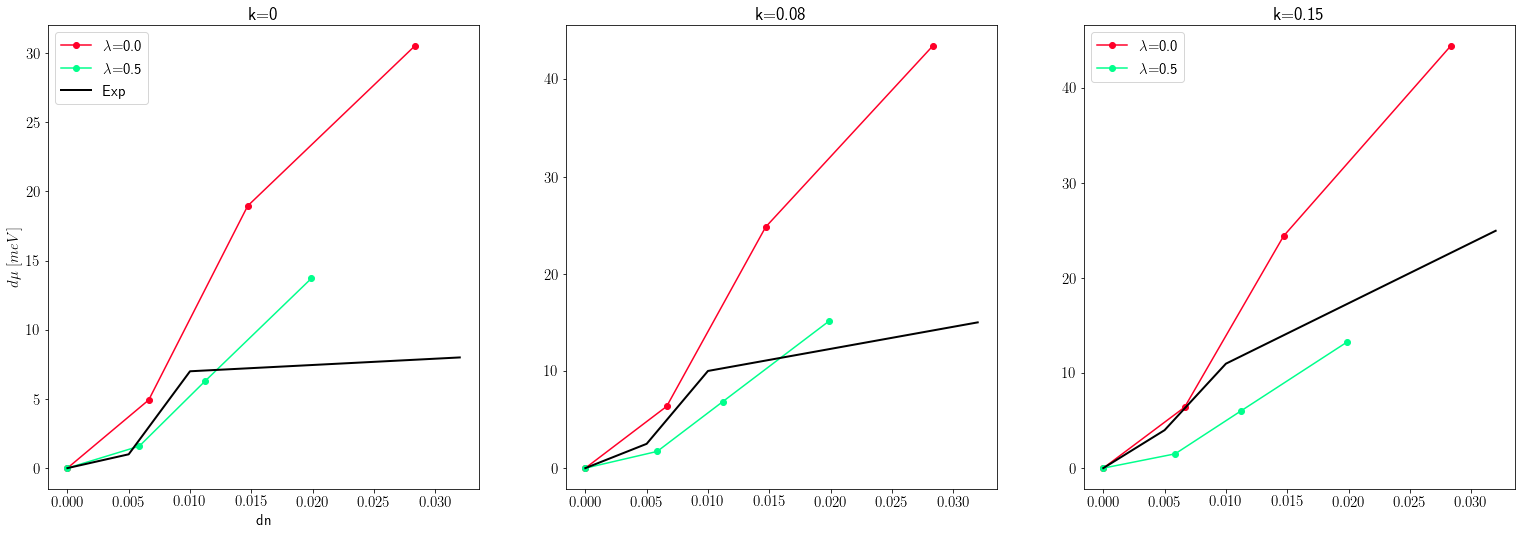

In [19]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.15
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.9

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow
print(int(1/len(lam)))

bath=False

ax0.plot(n_l0,(mu_l0_k0-mu_l0_k0[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda$=0.0")
# ax0.plot(n_l01,(mu_l01_k0-mu_l01_k0[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
ax0.plot(n_l05,(mu_l05_k0-mu_l05_k0[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
# ax0.plot(n_l1[:-1],(mu_l1_k0[:-1]-mu_l1_k0[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

if bath:
    ax0.plot(nB_l0,(muB_l0_k0-muB_l0_k0[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax0.plot(nB_l01,(muB_l01_k0-muB_l01_k0[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax0.plot(nB_l05,(muB_l05_k0-muB_l05_k0[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax0.plot(nB_l1[:-1],(muB_l1_k0[:-1]-muB_l1_k0[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")


fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,1,7,8])
ax0.plot(fluence,shift,"k-",lw=2,label="Exp")


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\mu~[meV]$")
ax0.set_title("k=0")

ax1.plot(n_l0,(mu_l0_k1-mu_l0_k1[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda$=0.0")
# ax1.plot(n_l01,(mu_l01_k1-mu_l01_k1[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
ax1.plot(n_l05,(mu_l05_k1-mu_l05_k1[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
# ax1.plot(n_l1[:-1],(mu_l1_k1[:-1]-mu_l1_k1[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

if bath:
    ax1.plot(nB_l0,(muB_l0_k1-muB_l0_k1[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax1.plot(nB_l01,(muB_l01_k1-muB_l01_k1[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax1.plot(nB_l05,(muB_l05_k1-muB_l05_k1[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax1.plot(nB_l1[:-1],(muB_l1_k1[:-1]-muB_l1_k1[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")



fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,2.5,10,15])
ax1.plot(fluence,shift,"k-",lw=2)
ax1.set_title("k=0.08")

ax2.plot(n_l0,(mu_l0_k2-mu_l0_k2[0])*1000,"b-",marker="o",color=colormap(0),label="$\lambda$=0.0")
# ax2.plot(n_l01,(mu_l01_k2-mu_l01_k2[0])*1000,"k-",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
ax2.plot(n_l05,(mu_l05_k2-mu_l05_k2[0])*1000,"r-",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
# ax2.plot(n_l1[:-1],(mu_l1_k2[:-1]-mu_l1_k2[0])*1000,"g-",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

if bath:
    ax2.plot(nB_l0,(muB_l0_k2-muB_l0_k2[0])*1000,ls="--",marker="o",color=colormap(0),label="$\lambda$=0.0")
    ax2.plot(nB_l01,(muB_l01_k2-muB_l01_k2[0])*1000,ls="--",color=colormap(1.0/len(lam)),marker="o",label="$\lambda$=0.1")
    ax2.plot(nB_l05,(muB_l05_k2-muB_l05_k2[0])*1000,ls="--",color=colormap(2.0/len(lam)),marker="o",label="$\lambda$=0.5")
    ax2.plot(nB_l1[:-1],(muB_l1_k2[:-1]-muB_l1_k2[0])*1000,ls="--",color=colormap(3.0/len(lam)),marker="o",label="$\lambda$=1")

fluence=np.array([0,0.005,0.01,0.032])
shift=np.array([0,4,11,25])
ax2.plot(fluence,shift,"k-",lw=2)
ax2.set_title("k=0.15")

ax0.set_xlabel("dn")
ax0.set_ylabel("$d\mu~[meV]$")

ax0.legend()

plt.legend()
# plt.savefig("fin/BEC_shift.pdf")

0


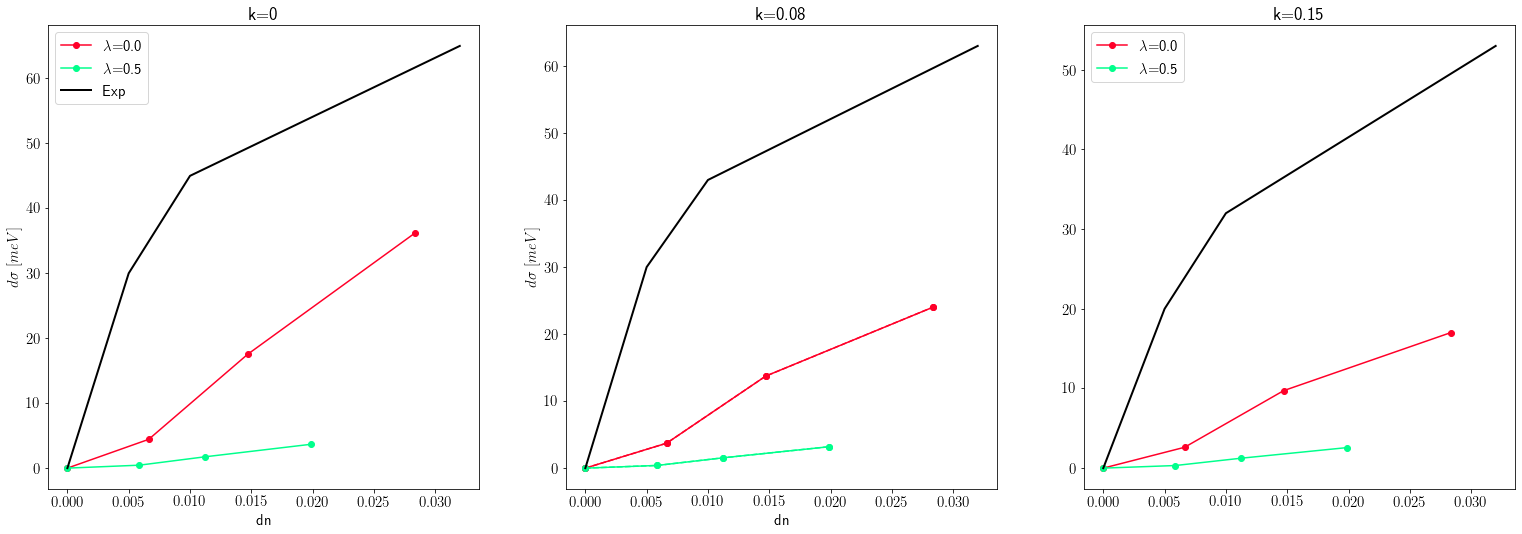

In [22]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6*3,8.6
mpl.rcParams["figure.subplot.left"] = 0.15
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.9

ax0 = plt.subplot(1,3,1)
ax1 = plt.subplot(1,3,2)
ax2 = plt.subplot(1,3,3)

lam=np.array([0,0.1,0.5,1.0])

colormap = plt.cm.gist_rainbow
print(int(1/len(lam)))

bath=False

ax0.plot(n_l0,(sigma_l0_k0-sigma_l0_k0[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax0.plot(n_l01,sigma_l01_k0*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax0.plot(n_l05,(sigma_l05_k0-sigma_l05_k0[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax0.plot(n_l1,sigma_l1_k0*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax0.plot(nB_l0,sigmaB_l0_k0*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax0.plot(nB_l01,sigmaB_l01_k0*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax0.plot(nB_l05,sigmaB_l05_k0*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax0.plot(nB_l1,sigmaB_l1_k0*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\sigma~[meV]$")
ax0.set_title("k=0")


ax1.plot(n_l0,(sigma_l0_k1-sigma_l0_k1[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax1.plot(n_l01,sigma_l01_k1*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax1.plot(n_l05,(sigma_l05_k1-sigma_l05_k1[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax1.plot(n_l1,sigma_l1_k1*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax1.plot(nB_l0,sigmaB_l0_k1*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax1.plot(nB_l01,sigmaB_l01_k1*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax1.plot(nB_l05,sigmaB_l05_k1*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax1.plot(nB_l1,sigmaB_l1_k1*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")


ax1.plot(n_l0,(sigma_l0_k1-sigma_l0_k1[0])*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax1.plot(n_l01,sigma_l01_k1*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax1.plot(n_l05,(sigma_l05_k1-sigma_l05_k1[0])*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax1.plot(n_l1,sigma_l1_k1*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")




ax1.set_xlabel("dn")
ax1.set_ylabel("$d\sigma~[meV]$")
ax1.set_title("k=0.08")


ax2.plot(n_l0,(sigma_l0_k2-sigma_l0_k2[0])*1000,marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
# ax2.plot(n_l01,sigma_l01_k2*1000,marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
ax2.plot(n_l05,(sigma_l05_k2-sigma_l05_k2[0])*1000,marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
# ax2.plot(n_l1,sigma_l1_k2*1000,marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")

if bath:
    ax2.plot(nB_l0,sigmaB_l0_k2*1000,ls="--",marker="o",color=colormap(0.0/len(lam)),label="$\lambda$=0.0")
    ax2.plot(nB_l01,sigmaB_l01_k2*1000,ls="--",marker="o",color=colormap(1.0/len(lam)),label="$\lambda$=0.1")
    ax2.plot(nB_l05,sigmaB_l05_k2*1000,ls="--",marker="o",color=colormap(2.0/len(lam)),label="$\lambda$=0.5")
    ax2.plot(nB_l1,sigmaB_l1_k2*1000,ls="--",marker="o",color=colormap(3.0/len(lam)),label="$\lambda$=1")
ax2.set_title("k=0.15")

fluence=np.array([0,0.005,0.01,0.032])
shift0=np.array([0,30,45,65])
shift1=np.array([0,30,43,63])
shift2=np.array([0,20,32,53])

ax0.plot(fluence,shift0,"k-",lw=2,label="Exp")
ax1.plot(fluence,shift1,"k-",lw=2)
ax2.plot(fluence,shift2,"k-",lw=2)


ax0.set_xlabel("dn")
ax0.set_ylabel("$d\sigma~[meV]$")
ax0.legend()

plt.legend()
plt.savefig("fin/BEC_sigma.pdf")

# Old versions of Fig3

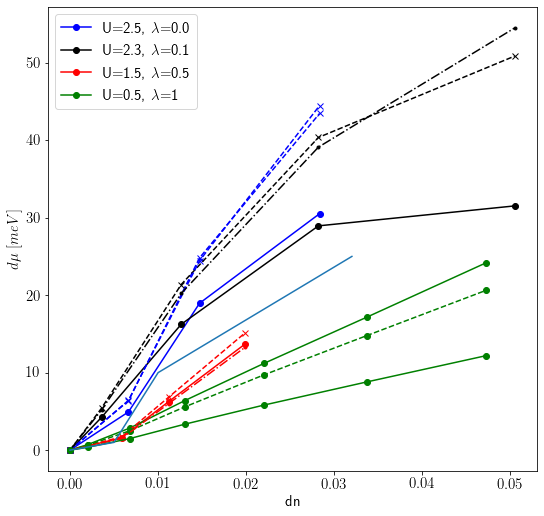

In [17]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6,8.6
mpl.rcParams["figure.subplot.left"] = 0.15
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.9

ax0 = plt.subplot(1,1,1)

ax0.plot(n_l0,(mu_l0_k0-mu_l0_k0[0])*1000,"b-",marker="o",label="U=2.5, $\lambda$=0.0")
ax0.plot(n_l01,(mu_l01_k0-mu_l01_k0[0])*1000,"k-",marker="o",label="U=2.3, $\lambda$=0.1")
ax0.plot(n_l05,(mu_l05_k0-mu_l05_k0[0])*1000,"r-",marker="o",label="U=1.5, $\lambda$=0.5")
ax0.plot(n_l1[:-1],(mu_l1_k0[:-1]-mu_l1_k0[0])*1000,"g-",marker="o",label="U=0.5, $\lambda$=1")


ax0.plot(n_l0,(mu_l0_k1-mu_l0_k1[0])*1000,"b--",marker="x")
ax0.plot(n_l01,(mu_l01_k1-mu_l01_k1[0])*1000,"k--",marker="x")
ax0.plot(n_l05,(mu_l05_k1-mu_l05_k1[0])*1000,"r--",marker="x")
ax0.plot(n_l1[:-1],(mu_l1_k1[:-1]-mu_l1_k1[0])*1000,"g--",marker="o")


ax0.plot(n_l0,(mu_l0_k2-mu_l0_k2[0])*1000,"b--",marker="x")
ax0.plot(n_l01,(mu_l01_k2-mu_l01_k2[0])*1000,"k-.",marker=".")
ax0.plot(n_l05,(mu_l05_k2-mu_l05_k2[0])*1000,"r-.",marker=".")
ax0.plot(n_l1[:-1],(mu_l1_k2[:-1]-mu_l1_k2[0])*1000,"g-",marker="o")

fluence=np.array([0,25,50,160])
shift=np.array([0,1,10,25])
ax0.plot(fluence/5000.0,shift)

ax0.set_xlabel("dn")
ax0.set_ylabel("$d\mu~[meV]$")

plt.legend()
# plt.savefig("fin/fig3a.svg")

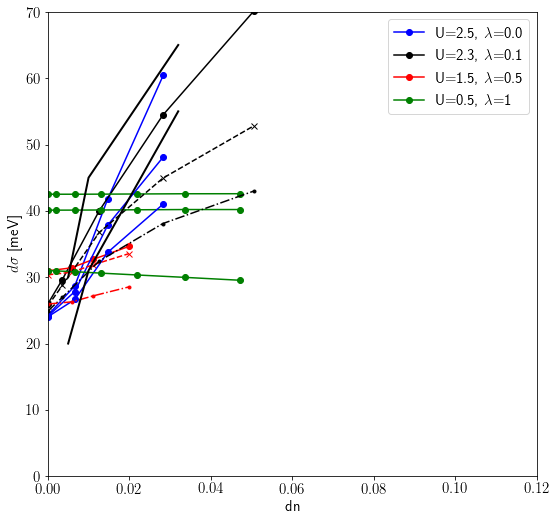

In [18]:
%matplotlib inline
mpl.rcParams['font.size'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['text.usetex'] = True
mpl.rcParams["figure.figsize"] = 8.6,8.6
mpl.rcParams["figure.subplot.left"] = 0.15
mpl.rcParams["figure.subplot.right"] = 0.94
mpl.rcParams["figure.subplot.bottom"] = 0.15
mpl.rcParams["figure.subplot.top"] = 0.9

ax0 = plt.subplot(1,1,1)

ax0.plot(n_l0,sigma_l0_k0*1000,"b-",marker="o",label="U=2.5, $\lambda$=0.0")
ax0.plot(n_l01,sigma_l01_k0*1000,"k-",marker="o",label="U=2.3, $\lambda$=0.1")
ax0.plot(n_l05,sigma_l05_k0*1000,"r-",marker="o",label="U=1.5, $\lambda$=0.5")
ax0.plot(n_l1[:-1],sigma_l1_k0[:-1]*1000,"g-",marker="o",label="U=0.5, $\lambda$=1")

ax0.plot(n_l0,sigma_l0_k1*1000,"b-",marker="o")
ax0.plot(n_l01,sigma_l01_k1*1000,"k--",marker="x")
ax0.plot(n_l05,sigma_l05_k1*1000,"r--",marker="x")
ax0.plot(n_l1[:-1],sigma_l1_k1[:-1]*1000,"g-",marker="o")

ax0.plot(n_l0,sigma_l0_k2*1000,"b-",marker="o")
ax0.plot(n_l01,sigma_l01_k2*1000,"k-.",marker=".")
ax0.plot(n_l05,sigma_l05_k2*1000,"r-.",marker=".")
ax0.plot(n_l1[:-1],sigma_l1_k2[:-1]*1000,"g-",marker="o")

fluence=np.array([25,50,160])
shift1=np.array([30,45,65])
shift2=np.array([20,31,55])
ax0.plot(fluence/5000.0,shift1,"k-",lw=2)
ax0.plot(fluence/5000.0,shift2,"k-",lw=2)

ax0.set_xlabel("dn")
ax0.set_ylabel("$d\sigma$~[meV]")

ax0.set_xlim(0,0.12)
ax0.set_ylim(0,70)


plt.legend()
plt.savefig("fin/fig3b.svg")